# OncoBridge — Architecture & Training Notebook v5
## ChemBERTa + Morgan FP Drug Encoder · Cross-Attention Fusion · Three-Split Evaluation
#
### Changes from v4 → v5:
| # | Change | Where | Impact |
|---|--------|-------|--------|
| C4 | Unfreeze last 2 transformer layers + LayerNorm of each modality encoder in Stage 2 (LR 5e-6) | Cell 9 | Patient repr adapts to drug-response features without destroying TCGA structure |
| C5 | Morgan FP (1024-bit ECFP4) projection fused with ChemBERTa CLS via concat → FusionProj in DrugEncoder | Cell 4, 5 | Substructure features generalise to cold drugs; ChemBERTa covers global SMILES semantics |
| C6 | Within-drug pairwise hinge ranking loss (weight=0.3, drug-cold only) | Cell 7 | Directly optimises AUROC-aligned objective; MSELoss alone doesn't penalise ranking inversions |
| C9 | Tanimoto-similarity ensemble at inference for drug-cold post-processing (top-k=5, threshold=0.2, blend=0.4) | Cell 10 | Zero-retraining boost: cold drug blends with structurally similar training drug predictions |
| C10 | Checkpoint by avg_drug_auroc for drug-cold; GlobalPCC for warm/cell-cold | Cell 8, 9 | Checkpoint metric aligned with primary evaluation metric per split |
#
### Architecture (v5):
```
mRNA + CNV + Mutation + Methylation
              ↓
 OncoBridgeMMCAT_v7 backbone
  Stage 1: fully FROZEN
  Stage 2: cross_layers + fusion + LAST 2 LAYERS of each modality encoder unfrozen
              ↓
  1920-dim patient embedding [5 × 384-dim CLS tokens] (K, V)
#
 Drug SMILES               Morgan FP (1024-bit ECFP4)   ← NEW C5
      ↓                             ↓
ChemBERTa-77M-MLM        Morgan Projection (1024→192)   ← NEW C5
 (first 6 layers frozen)           ↓
CLS → smiles_proj (→192)     morgan_emb (192)            ← NEW C5
      └────────────────────────────┘
             concat (384) → fusion_proj → 384-dim drug embedding (Q)
              ↓                      ↓
   Cross-Attention: Drug(Q) × Patient(K,V)
              ↓
    Regression MLP → LN(IC50)
              ↓ [drug-cold only]
 + Within-drug Pairwise Ranking Loss (weight=0.3)        ← NEW C6
              ↓ [drug-cold inference only]
 + Tanimoto Ensemble (top-k similar training drugs)      ← NEW C9
```
#
### Split Modes:
| Mode | Description | Use Case | Checkpoint Metric |
|------|-------------|----------|-------------------|
| `warm` | Random 80/10/10 IC50-pair split | Standard benchmark | GlobalPCC |
| `cell_cold` | 20% cell lines held out | Generalisation to new cancer lines | GlobalPCC |
| `drug_cold` | 15% drugs held out (scaffold-based) | Generalisation to novel compounds | avg_drug_auroc |

In [1]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 1 — INSTALLS & IMPORTS
# ═══════════════════════════════════════════════════════════════════════
import subprocess, sys

def pip(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *pkgs], check=True)

pip('transformers', 'accelerate')
print('✓ transformers  ✓ accelerate installed.')

import os, gc, json, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint as grad_checkpoint

from transformers import AutoTokenizer, AutoModel

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score
from sklearn.decomposition import PCA

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_theme(style='whitegrid')

def section(t):
    print('\n' + '═'*70)
    print(f'  {t}')
    print('═'*70)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPUS = torch.cuda.device_count()
print(f'\nDevice: {DEVICE} | GPUs available: {N_GPUS}')
for i in range(N_GPUS):
    props = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {props.name} | {props.total_memory/1e9:.1f} GB VRAM')
print()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 97.6 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

✓ transformers  ✓ accelerate installed.

Device: cuda | GPUs available: 2
  GPU 0: Tesla T4 | 15.6 GB VRAM
  GPU 1: Tesla T4 | 15.6 GB VRAM



In [2]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 2 — CONFIG
#
#  ★ KEY KNOB — set SPLIT_MODE to choose which split is used for
#    training, validation, AND test evaluation.
#
#    'warm'       → random IC50-pair split     (default, matches most papers)
#    'cell_cold'  → cell lines held-out test   (harder; tests generalisation)
#    'drug_cold'  → drugs held-out test        (hardest; novel compound setting)
#
#  v5 NEW CONFIG ENTRIES:
#    morgan_fp_path / morgan_fp_order_path   — pre-computed ECFP4 FP files (C5)
#    morgan_dim                              — fingerprint dimension = 1024 (C5)
#    ranking_loss_weight                     — pairwise ranking aux loss (C6)
#    stage2_unfreeze_mod_layers              — last N encoder layers to unfreeze (C4)
#    stage2_lr_mod_enc                       — LR for those newly unfrozen layers (C4)
#    tanimoto_*                              — Tanimoto ensemble params (C9)
# ═══════════════════════════════════════════════════════════════════════

SPLIT_MODE = 'drug_cold'   # Options: 'warm' | 'cell_cold' | 'drug_cold'
assert SPLIT_MODE in ('warm', 'cell_cold', 'drug_cold'), \
    f'Unknown SPLIT_MODE: {SPLIT_MODE!r}'

DATA_BASE  = '/kaggle/input/datasets/proutkarshtiwari/smiles2-training-data'
CKPT_PATH  = '/kaggle/input/models/proutkarshtiwari/oncobridgev7-95-74acc/pytorch/default/1/oncobridge_v7_best.pt'
OUT_DIR    = '/kaggle/working/'

PATH_MRNA       = f'{DATA_BASE}/ccle_mrna_scaled.parquet'
PATH_CNV        = f'{DATA_BASE}/ccle_cnv_scaled.parquet'
PATH_MUT        = f'{DATA_BASE}/ccle_mut_scaled.parquet'
PATH_METH       = f'{DATA_BASE}/ccle_meth_scaled.parquet'
PATH_SMILES     = f'{DATA_BASE}/drug_smiles.json'
PATH_DRUG_NAMES = f'{DATA_BASE}/valid_drug_names.csv'
PATH_DRUG2IDX   = f'{DATA_BASE}/drug2idx.json'

SPLIT_PATHS = {
    'warm': {
        'train': f'{DATA_BASE}/split_warm_tr.parquet',
        'val':   f'{DATA_BASE}/split_warm_vl.parquet',
        'test':  f'{DATA_BASE}/split_warm_te.parquet',
    },
    'cell_cold': {
        'train': f'{DATA_BASE}/split_cc_tr.parquet',
        'val':   f'{DATA_BASE}/split_cc_vl.parquet',
        'test':  f'{DATA_BASE}/split_cc_te.parquet',
    },
    'drug_cold': {
        'train': f'{DATA_BASE}/split_dc_tr.parquet',
        'val':   f'{DATA_BASE}/split_dc_vl.parquet',
        'test':  f'{DATA_BASE}/split_dc_te.parquet',
    },
}

CONFIG = {
    # ── Omics backbone dimensions (must match Phase 1 checkpoint) ──────
    'num_mrna_genes': 8011,
    'num_cnv_genes':  3500,
    'num_mut_genes':  2500,
    'num_meth_genes': 6000,
    # ── MMCAT v7 architecture ──────────────────────────────────────────
    'embed_dim':          384,
    'num_heads':          8,
    'num_encoder_layers': 6,
    'num_cross_layers':   4,
    'cnn_kernel':         16,
    'cnn_stride':         16,
    'ff_dim':             1536,
    'dropout':            0.20,
    'gate_init':          1.5,
    'use_grad_ckpt':      False,
    'num_classes':        22,
    # ── ChemBERTa ─────────────────────────────────────────────────────
    'chemberta_model':         'DeepChem/ChemBERTa-77M-MLM',
    'chemberta_dim':           384,
    'chemberta_max_len':       512,
    'chemberta_freeze_layers': 6,
    # ── [C5] Morgan fingerprints ───────────────────────────────────────
    'morgan_fp_path':       f'{DATA_BASE}/drug_morgan_fps.npy',
    'morgan_fp_order_path': f'{DATA_BASE}/drug_morgan_fp_order.json',
    'morgan_dim':           1024,   # ECFP4 bit-vector length
    # ── Fusion & regression head ───────────────────────────────────────
    'fusion_heads':    8,
    'fusion_dropout':  0.20,
    # ── Training ──────────────────────────────────────────────────────
    'batch_size':    32,
    'grad_accum':    4,
    'num_workers':   4,
    'use_amp':       True,
    'clip_grad':     1.0,
    'warmup_frac':   0.10,
    # Stage 1: head + cross-attention + ChemBERTa upper layers
    'stage1_epochs':   25,
    'stage1_lr':       5e-4,
    'stage1_wd':       1e-4,
    'stage1_patience': 7,
    # Stage 2: + backbone cross_layers/fusion + last-N modality enc layers
    'stage2_epochs':    30,
    'stage2_lr_head':   1e-4,
    'stage2_lr_cross':  5e-5,
    'stage2_lr_cbert':  2e-5,
    'stage2_lr_proj':   1e-4,
    'stage2_lr_mod_enc': 5e-6,       # [C4] last-N modality encoder layers
    'stage2_unfreeze_mod_layers': 2, # [C4] how many trailing layers to unfreeze
    'stage2_wd':        1e-4,
    'stage2_patience':  10,
    # ── [C6] Pairwise ranking loss (drug-cold only) ────────────────────
    'ranking_loss_weight': 0.30,
    # ── [C9] Tanimoto ensemble (drug-cold inference only) ─────────────
    'tanimoto_top_k':        5,
    'tanimoto_threshold':    0.20,
    'tanimoto_blend_weight': 0.40,
    # ── Checkpoint path ───────────────────────────────────────────────
    'checkpoint_ft': f'{OUT_DIR}oncobridge_chemberta_v5_best.pt',
    'split_mode': SPLIT_MODE,
}

# [C10] Primary checkpoint metric per split mode
CKPT_METRIC = 'avg_drug_auroc' if SPLIT_MODE == 'drug_cold' else 'pearson'

eff_batch = CONFIG['batch_size'] * max(N_GPUS, 1) * CONFIG['grad_accum']
print(f'\n{"="*65}')
print(f'  ★ SPLIT MODE    : {SPLIT_MODE.upper()}')
print(f'  ★ CKPT METRIC   : {CKPT_METRIC}')          # [C10]
print(f'  Train path      : {SPLIT_PATHS[SPLIT_MODE]["train"]}')
print(f'  Effective batch : {eff_batch}')
print(f'  ChemBERTa       : {CONFIG["chemberta_model"]}')
print(f'  Frozen layers   : first {CONFIG["chemberta_freeze_layers"]} transformer blocks')
print(f'  Morgan FP dim   : {CONFIG["morgan_dim"]}')  # [C5]
print(f'  Rank loss wt    : {CONFIG["ranking_loss_weight"]} (drug-cold only)')  # [C6]
print(f'  S2 unfreeze     : last {CONFIG["stage2_unfreeze_mod_layers"]} modality enc layers (lr={CONFIG["stage2_lr_mod_enc"]:.0e})')  # [C4]
print(f'{"="*65}')


  ★ SPLIT MODE    : DRUG_COLD
  ★ CKPT METRIC   : avg_drug_auroc
  Train path      : /kaggle/input/datasets/proutkarshtiwari/smiles2-training-data/split_dc_tr.parquet
  Effective batch : 256
  ChemBERTa       : DeepChem/ChemBERTa-77M-MLM
  Frozen layers   : first 6 transformer blocks
  Morgan FP dim   : 1024
  Rank loss wt    : 0.3 (drug-cold only)
  S2 unfreeze     : last 2 modality enc layers (lr=5e-06)


In [3]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 3 — LOAD PROCESSED DATA & SPLITS
#  [C5] Also loads Morgan fingerprint matrix and builds drug→row-index map.
# ═══════════════════════════════════════════════════════════════════════
section('3. LOAD PROCESSED DATA')

t0 = time.time()
mrna_df = pd.read_parquet(PATH_MRNA)
cnv_df  = pd.read_parquet(PATH_CNV)
mut_df  = pd.read_parquet(PATH_MUT)
meth_df = pd.read_parquet(PATH_METH)
print(f'Loaded omics in {time.time()-t0:.1f}s')
print(f'mRNA {mrna_df.shape} | CNV {cnv_df.shape} | Mut {mut_df.shape} | Meth {meth_df.shape}')

with open(PATH_SMILES)   as f: smiles_map = json.load(f)
with open(PATH_DRUG2IDX) as f: drug2idx   = json.load(f)
DRUG_NAMES = pd.read_csv(PATH_DRUG_NAMES, header=None)[0].tolist()
id_to_drug = {int(i): d for d, i in drug2idx.items()}
n_drugs    = len(DRUG_NAMES)
print(f'Drugs: {n_drugs} | SMILES available: {sum(1 for v in smiles_map.values() if v)}')

# ── [C5] Morgan fingerprints ──────────────────────────────────────────
morgan_fp_matrix = np.load(CONFIG['morgan_fp_path']).astype(np.float32)  # (74, 1024)
with open(CONFIG['morgan_fp_order_path']) as f:
    morgan_fp_order = json.load(f)
drug_to_morgan_idx = {d: i for i, d in enumerate(morgan_fp_order)}
print(f'Morgan FP matrix : {morgan_fp_matrix.shape}  '
      f'| Drug coverage : {len(drug_to_morgan_idx)} / {n_drugs}')
_missing_fp = [d for d in DRUG_NAMES if d not in drug_to_morgan_idx]
if _missing_fp:
    print(f'  [warn] {len(_missing_fp)} drugs missing from Morgan FP order; '
          f'will use row-0 as fallback: {_missing_fp[:5]}')
# ─────────────────────────────────────────────────────────────────────

all_cell_lines = sorted(mrna_df.index.tolist())
cl_to_idx = {cl: i for i, cl in enumerate(all_cell_lines)}

mrna_arr = mrna_df.loc[all_cell_lines].values.astype(np.float32)
cnv_arr  = cnv_df.loc[all_cell_lines].values.astype(np.float32)
mut_arr  = mut_df.loc[all_cell_lines].values.astype(np.float32)
meth_arr = meth_df.loc[all_cell_lines].values.astype(np.float32)

total_mb = (mrna_arr.nbytes + cnv_arr.nbytes + mut_arr.nbytes + meth_arr.nbytes) / 1e6
print(f'Omics RAM: {total_mb:.0f} MB (pre-stacked)')

def load_and_map_split(path):
    df = pd.read_parquet(path)
    df['cl_idx']   = df['ModelID'].map(cl_to_idx)
    df['drug_idx'] = df['DRUG_NAME'].map(drug2idx)
    before = len(df)
    df = df.dropna(subset=['cl_idx', 'drug_idx'])
    if len(df) < before:
        print(f'    [warn] {before - len(df)} rows dropped (unmatched CL/drug) '
              f'in {path.split("/")[-1]}')
    df['cl_idx']   = df['cl_idx'].astype(int)
    df['drug_idx'] = df['drug_idx'].astype(int)
    return df

print(f'\nLoading SPLIT_MODE = "{SPLIT_MODE}" train/val/test splits...')
ic50_train = load_and_map_split(SPLIT_PATHS[SPLIT_MODE]['train'])
ic50_val   = load_and_map_split(SPLIT_PATHS[SPLIT_MODE]['val'])
ic50_test  = load_and_map_split(SPLIT_PATHS[SPLIT_MODE]['test'])

print(f'  [{SPLIT_MODE}] Train: {len(ic50_train):>7,} pairs')
print(f'  [{SPLIT_MODE}] Val:   {len(ic50_val):>7,} pairs')
print(f'  [{SPLIT_MODE}] Test:  {len(ic50_test):>7,} pairs  ← evaluation set')

del mrna_df, cnv_df, mut_df, meth_df; gc.collect()
print('\nOriginal parquet DFs freed from memory.')


══════════════════════════════════════════════════════════════════════
  3. LOAD PROCESSED DATA
══════════════════════════════════════════════════════════════════════
Loaded omics in 1.8s
mRNA (388, 8011) | CNV (388, 3500) | Mut (388, 2500) | Meth (388, 6000)
Drugs: 74 | SMILES available: 74
Morgan FP matrix : (74, 1024)  | Drug coverage : 74 / 74
Omics RAM: 31 MB (pre-stacked)

Loading SPLIT_MODE = "drug_cold" train/val/test splits...
  [drug_cold] Train:   7,270 pairs
  [drug_cold] Val:       808 pairs
  [drug_cold] Test:    1,889 pairs  ← evaluation set

Original parquet DFs freed from memory.


In [4]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 4 — DATASET & DATALOADERS
#  [C5] DrugResponseDataset now returns `morgan_fp` tensor per sample.
# ═══════════════════════════════════════════════════════════════════════
section('4. DATASET & DATALOADERS')

print(f'Loading ChemBERTa tokenizer: {CONFIG["chemberta_model"]}')
tokenizer = AutoTokenizer.from_pretrained(CONFIG['chemberta_model'])
print(f'Tokenizer vocab size: {tokenizer.vocab_size}')


class DrugResponseDataset(Dataset):
    """
    Multi-omics drug-response dataset.

    [C5] Additions: stores `morgan_fp_matrix` and `drug_to_morgan_idx`.
    __getitem__ returns `morgan_fp` (float32, shape [morgan_dim]) in addition
    to the SMILES tokenisation.  Drugs without an entry fall back to row-0
    (a valid fingerprint, not a zero vector).
    """
    def __init__(self, df, mrna_arr, cnv_arr, mut_arr, meth_arr,
                 smiles_map, tokenizer,
                 morgan_fp_matrix, drug_to_morgan_idx,   # [C5]
                 max_len=512):
        self.cl_idx     = df['cl_idx'].values.astype(np.int32)
        self.drug_idx   = df['drug_idx'].values.astype(np.int64)
        self.ic50       = df['ic50_value'].values.astype(np.float32)
        self.drug_names = df['DRUG_NAME'].values
        self.mrna_arr   = mrna_arr
        self.cnv_arr    = cnv_arr
        self.mut_arr    = mut_arr
        self.meth_arr   = meth_arr
        self.smiles_map = smiles_map
        self.tokenizer  = tokenizer
        self.max_len    = max_len
        # [C5]
        self.morgan_fp_matrix   = morgan_fp_matrix
        self.drug_to_morgan_idx = drug_to_morgan_idx

    def __len__(self): return len(self.ic50)

    def __getitem__(self, idx):
        ci   = int(self.cl_idx[idx])
        did  = int(self.drug_idx[idx])
        dname = self.drug_names[idx]

        mrna = torch.from_numpy(self.mrna_arr[ci].copy())
        cnv  = torch.from_numpy(self.cnv_arr[ci].copy())
        mut  = torch.from_numpy(self.mut_arr[ci].copy())
        meth = torch.from_numpy(self.meth_arr[ci].copy())

        smiles = self.smiles_map.get(dname, 'C') or 'C'
        enc = self.tokenizer(
            smiles, max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt')

        # [C5] Morgan fingerprint — fall back to row-0 if drug unknown
        fp_row = self.drug_to_morgan_idx.get(dname, 0)
        morgan_fp = torch.from_numpy(self.morgan_fp_matrix[fp_row].copy())

        return {
            'mrna':           mrna,
            'cnv':            cnv,
            'mut':            mut,
            'meth':           meth,
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'morgan_fp':      morgan_fp,    # [C5]  shape: (morgan_dim,)
            'ic50':           torch.tensor(self.ic50[idx]),
            'drug_idx':       torch.tensor(did),
        }


def make_loader(df, shuffle, bs_mult=1):
    ds = DrugResponseDataset(
        df, mrna_arr, cnv_arr, mut_arr, meth_arr,
        smiles_map, tokenizer,
        morgan_fp_matrix, drug_to_morgan_idx,   # [C5]
        CONFIG['chemberta_max_len'])
    return DataLoader(
        ds,
        batch_size=CONFIG['batch_size'] * bs_mult,
        shuffle=shuffle,
        num_workers=CONFIG['num_workers'],
        pin_memory=True,
        persistent_workers=(CONFIG['num_workers'] > 0),
        prefetch_factor=2 if CONFIG['num_workers'] > 0 else None,
        drop_last=shuffle,
    ), ds


train_loader, train_ds = make_loader(ic50_train, shuffle=True)
val_loader,   val_ds   = make_loader(ic50_val,   shuffle=False, bs_mult=2)
test_loader,  test_ds  = make_loader(ic50_test,  shuffle=False, bs_mult=2)

batch = next(iter(train_loader))
print(f'\nSanity check (SPLIT_MODE = {SPLIT_MODE!r}):')
print(f'  mRNA shape:        {batch["mrna"].shape}')
print(f'  input_ids shape:   {batch["input_ids"].shape}')
print(f'  morgan_fp shape:   {batch["morgan_fp"].shape}')   # [C5]
print(f'  IC50 range:        [{batch["ic50"].min():.2f}, {batch["ic50"].max():.2f}]')
print(f'  Train batches:     {len(train_loader)}')
print(f'  Val   batches:     {len(val_loader)}')
print(f'  Test  batches:     {len(test_loader)}  ← evaluation set')


══════════════════════════════════════════════════════════════════════
  4. DATASET & DATALOADERS
══════════════════════════════════════════════════════════════════════
Loading ChemBERTa tokenizer: DeepChem/ChemBERTa-77M-MLM


config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/420 [00:00<?, ?B/s]

Tokenizer vocab size: 591

Sanity check (SPLIT_MODE = 'drug_cold'):
  mRNA shape:        torch.Size([32, 8011])
  input_ids shape:   torch.Size([32, 512])
  morgan_fp shape:   torch.Size([32, 1024])
  IC50 range:        [-6.27, 2.14]
  Train batches:     227
  Val   batches:     13
  Test  batches:     30  ← evaluation set


In [5]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 5 — MODEL ARCHITECTURE
#
#  Backbone classes (GeneImportanceLayer, ModalityEncoder, CrossModalAttention4,
#  GatedFusion4, OncoBridgeMMCAT_v7) are UNCHANGED from v4.
#
#  [C5] ChemBERTaDrugEncoder:
#    Old: single `proj`  (hidden_size → drug_embed_dim)
#    New: `smiles_proj`  (hidden_size → half_dim)       ← ChemBERTa CLS branch
#         `morgan_proj`  (morgan_dim  → half_dim)       ← Morgan FP branch
#         `fusion_proj`  (drug_embed_dim → drug_embed_dim) ← combine
#    forward() now takes `morgan_fp` as a required argument.
#
#  [C5] OncoBridgeDrugResponse.forward():
#    Passes `morgan_fp` through to drug_encoder.
# ═══════════════════════════════════════════════════════════════════════
section('5. MODEL ARCHITECTURE')

# ── Backbone (unchanged) ─────────────────────────────────────────────

class GeneImportanceLayer(nn.Module):
    def __init__(self, num_genes, init_val=1.5):
        super().__init__()
        self.logits = nn.Parameter(torch.full((num_genes,), init_val))
    def forward(self, x):
        return x * torch.sigmoid(self.logits)


class ModalityEncoder(nn.Module):
    def __init__(self, num_genes, embed_dim, num_heads, num_layers,
                 cnn_kernel, cnn_stride, ff_dim, dropout, gate_init=1.5, use_ckpt=False):
        super().__init__()
        self.use_ckpt   = use_ckpt
        self.gene_gate  = GeneImportanceLayer(num_genes, init_val=gate_init)
        self.input_proj = nn.Linear(1, embed_dim)
        self.cnn = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim, kernel_size=cnn_kernel,
                      stride=cnn_stride, padding=cnn_kernel // 2),
            nn.GELU(), nn.BatchNorm1d(embed_dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        compressed = (num_genes + cnn_kernel // 2 * 2 - cnn_kernel) // cnn_stride + 1 + 1
        self.pos_emb = nn.Parameter(torch.randn(1, compressed, embed_dim) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)

    def _tfm(self, x): return self.transformer(x)

    def forward(self, x):
        x = self.gene_gate(x).unsqueeze(-1)
        x = self.input_proj(x).transpose(1, 2)
        x = self.cnn(x).transpose(1, 2)
        B = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_emb[:, :x.size(1) + 1, :]
        x = (grad_checkpoint(self._tfm, x, use_reentrant=False)
             if self.use_ckpt and self.training else self._tfm(x))
        return self.norm(x)


class CrossModalAttention4(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()
        mods = ['mrna', 'cnv', 'mut', 'meth']
        self.cross_attns = nn.ModuleDict({
            m: nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
            for m in mods})
        self.q_norms = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})
        def ffn():
            return nn.Sequential(
                nn.Linear(embed_dim, ff_dim), nn.GELU(), nn.Dropout(dropout),
                nn.Linear(ff_dim, embed_dim), nn.Dropout(dropout))
        self.ffns      = nn.ModuleDict({m: ffn() for m in mods})
        self.ffn_norms = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})

    def forward(self, mrna_seq, cnv_seq, mut_seq, meth_seq):
        seqs = {'mrna': mrna_seq, 'cnv': cnv_seq, 'mut': mut_seq, 'meth': meth_seq}
        out  = {}
        for m, q_seq in seqs.items():
            others = torch.cat([s for k, s in seqs.items() if k != m], dim=1)
            q = self.q_norms[m](q_seq)
            h, _ = self.cross_attns[m](q, others, others, need_weights=False)
            ao = q_seq + h
            out[m] = ao + self.ffns[m](self.ffn_norms[m](ao))
        return out['mrna'], out['cnv'], out['mut'], out['meth']


class GatedFusion4(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.gate = nn.Linear(embed_dim * 4, 4)
    def forward(self, m, c, u, e):
        g = F.softmax(self.gate(torch.cat([m, c, u, e], dim=-1)), dim=-1)
        return g[:, 0:1]*m + g[:, 1:2]*c + g[:, 2:3]*u + g[:, 3:4]*e, g


class OncoBridgeMMCAT_v7(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        E, H, NL, NC = cfg['embed_dim'], cfg['num_heads'], cfg['num_encoder_layers'], cfg['num_cross_layers']
        K, S, FF, D  = cfg['cnn_kernel'], cfg['cnn_stride'], cfg['ff_dim'], cfg['dropout']
        GI, UC       = cfg['gate_init'], cfg['use_grad_ckpt']
        self.mrna_enc     = ModalityEncoder(cfg['num_mrna_genes'], E, H, NL, K, S, FF, D, GI, UC)
        self.cnv_enc      = ModalityEncoder(cfg['num_cnv_genes'],  E, H, NL, K, S, FF, D, GI, UC)
        self.mut_enc      = ModalityEncoder(cfg['num_mut_genes'],  E, H, NL, K, S, FF, D, GI, UC)
        self.meth_enc     = ModalityEncoder(cfg['num_meth_genes'], E, H, NL, K, S, FF, D, GI, UC)
        self.cross_layers = nn.ModuleList([CrossModalAttention4(E, H, FF, D) for _ in range(NC)])
        self.fusion       = GatedFusion4(E)
        self.classifier   = nn.Sequential(
            nn.LayerNorm(E*5), nn.Linear(E*5, E*2), nn.GELU(), nn.Dropout(D),
            nn.Linear(E*2, E), nn.GELU(), nn.Dropout(D), nn.Linear(E, cfg['num_classes']))

    def forward(self, mrna, cnv, mut, meth):
        ms = self.mrna_enc(mrna); cs = self.cnv_enc(cnv)
        us = self.mut_enc(mut);   es = self.meth_enc(meth)
        for layer in self.cross_layers:
            ms, cs, us, es = layer(ms, cs, us, es)
        cm = ms[:, 0]; cc = cs[:, 0]; cu = us[:, 0]; ce = es[:, 0]
        fused, gates = self.fusion(cm, cc, cu, ce)
        return self.classifier(torch.cat([cm, cc, cu, ce, fused], dim=-1))


# ── [C5] Drug Encoder — ChemBERTa + Morgan FP ─────────────────────────
class ChemBERTaDrugEncoder(nn.Module):
    """
    Dual-branch drug encoder.

    Branch 1 (SMILES):  ChemBERTa-77M → [CLS] → smiles_proj → 192-dim
    Branch 2 (Morgan):  1024-bit ECFP4 → morgan_proj         → 192-dim
    Fusion:             concat(192, 192) → fusion_proj        → 384-dim

    The 384-dim output matches `cfg['chemberta_dim']`, so downstream modules
    (DrugPatientCrossAttention, regression head) are unchanged.

    Design rationale (C5):
      ChemBERTa captures global SMILES semantics but is sensitive to SMILES
      ordering and trained-attention patterns that may not generalise to cold
      drugs.  Morgan FPs are substructure-based and order-agnostic: two
      molecules with similar pharmacophores will have similar ECFP4 vectors
      regardless of SMILES notation.  The concat-fusion combines both views,
      improving cold-drug generalisation while preserving learned chemistry.
    """
    def __init__(self, model_name, drug_embed_dim, freeze_n_layers=6,
                 dropout=0.1, morgan_dim=1024):
        super().__init__()
        assert drug_embed_dim % 2 == 0, 'drug_embed_dim must be even'
        half_dim = drug_embed_dim // 2

        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size  = self.encoder.config.hidden_size

        # Freeze embedding layer
        for p in self.encoder.embeddings.parameters():
            p.requires_grad = False
        # Freeze first `freeze_n_layers` transformer blocks
        for i, layer in enumerate(self.encoder.encoder.layer):
            if i < freeze_n_layers:
                for p in layer.parameters():
                    p.requires_grad = False

        n_tr  = sum(p.numel() for p in self.encoder.parameters() if p.requires_grad)
        n_tot = sum(p.numel() for p in self.encoder.parameters())
        print(f'  ChemBERTa: {n_tot:,} total | {n_tr:,} trainable '
              f'(layers {freeze_n_layers}+)')

        # SMILES branch projection (hidden_size → half_dim)
        self.smiles_proj = nn.Sequential(
            nn.Linear(hidden_size, half_dim), nn.GELU(),
            nn.Dropout(dropout), nn.LayerNorm(half_dim))

        # Morgan FP branch projection (morgan_dim → half_dim)  [C5]
        self.morgan_proj = nn.Sequential(
            nn.Linear(morgan_dim, half_dim), nn.GELU(),
            nn.Dropout(dropout), nn.LayerNorm(half_dim))

        # Fusion: concat(half, half) → drug_embed_dim  [C5]
        self.fusion_proj = nn.Sequential(
            nn.Linear(drug_embed_dim, drug_embed_dim),
            nn.LayerNorm(drug_embed_dim))

        self.drug_embed_dim = drug_embed_dim

    def forward(self, input_ids, attention_mask, morgan_fp):  # [C5] added morgan_fp
        out        = self.encoder(input_ids=input_ids,
                                  attention_mask=attention_mask)
        smiles_emb = self.smiles_proj(out.last_hidden_state[:, 0, :])  # (B, half_dim)
        morgan_emb = self.morgan_proj(morgan_fp)                        # (B, half_dim)
        combined   = torch.cat([smiles_emb, morgan_emb], dim=-1)       # (B, drug_embed_dim)
        return self.fusion_proj(combined)                               # (B, drug_embed_dim)


class DrugPatientCrossAttention(nn.Module):
    """
    Drug embedding (Q) attends over tokenised patient embedding (K, V).

    patient_embed : (B, 1920)  → viewed as 5 × 384-dim tokens
    drug_embed    : (B, 384)   → projected query
    """
    def __init__(self, patient_dim, drug_embed_dim, embed_dim, num_heads,
                 dropout, output_dim):
        super().__init__()
        assert patient_dim % embed_dim == 0
        self.n_patient_tokens = patient_dim // embed_dim
        self.embed_dim        = embed_dim
        self.drug_proj  = nn.Sequential(nn.Linear(drug_embed_dim, embed_dim),
                                        nn.LayerNorm(embed_dim))
        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads,
                                                dropout=dropout, batch_first=True)
        self.attn_norm  = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim), nn.Dropout(dropout))
        self.ffn_norm = nn.LayerNorm(embed_dim)
        combined = embed_dim + drug_embed_dim
        self.output_mlp = nn.Sequential(
            nn.Linear(combined, combined // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(combined // 2, output_dim), nn.LayerNorm(output_dim))

    def forward(self, patient_embed, drug_embed):
        B = patient_embed.size(0)
        patient_tokens = patient_embed.view(B, self.n_patient_tokens, self.embed_dim)
        drug_query = self.drug_proj(drug_embed).unsqueeze(1)
        attn_out, attn_w = self.cross_attn(drug_query, patient_tokens, patient_tokens,
                                           need_weights=True)
        attn_out = self.attn_norm(drug_query + attn_out)
        ffn_out  = self.ffn_norm(attn_out + self.ffn(attn_out))
        combined = torch.cat([ffn_out.squeeze(1), drug_embed], dim=-1)
        return self.output_mlp(combined), attn_w


class OncoBridgeDrugResponse(nn.Module):
    """
    Full OncoBridge Phase-2 model.

    [C5] forward() now accepts `morgan_fp` and passes it to drug_encoder.
    """
    def __init__(self, backbone, cfg):
        super().__init__()
        self.backbone       = backbone
        self.freeze_backbone = True
        patient_dim   = cfg['embed_dim'] * 5   # 384 * 5 = 1920
        self.drug_encoder = ChemBERTaDrugEncoder(
            cfg['chemberta_model'],
            cfg['chemberta_dim'],
            cfg['chemberta_freeze_layers'],
            cfg['fusion_dropout'],
            cfg['morgan_dim'],          # [C5]
        )
        fusion_out_dim = 512
        self.fusion = DrugPatientCrossAttention(
            patient_dim   = patient_dim,
            drug_embed_dim= cfg['chemberta_dim'],
            embed_dim     = cfg['embed_dim'],
            num_heads     = cfg['fusion_heads'],
            dropout       = cfg['fusion_dropout'],
            output_dim    = fusion_out_dim)
        self.regression_head = nn.Sequential(
            nn.LayerNorm(fusion_out_dim),
            nn.Linear(fusion_out_dim, 256), nn.GELU(), nn.Dropout(cfg['fusion_dropout']),
            nn.Linear(256, 64),             nn.GELU(), nn.Dropout(cfg['fusion_dropout']),
            nn.Linear(64, 1))

    def forward(self, mrna, cnv, mut, meth, input_ids, attention_mask,
                morgan_fp):   # [C5] added morgan_fp
        if self.freeze_backbone:
            with torch.no_grad():
                patient_embed = self.backbone(mrna, cnv, mut, meth)
        else:
            patient_embed = self.backbone(mrna, cnv, mut, meth)
        drug_embed = self.drug_encoder(input_ids, attention_mask, morgan_fp)  # [C5]
        fused, attn_w = self.fusion(patient_embed, drug_embed)
        return self.regression_head(fused)


print('\nAll model classes defined.')
print('Fusion: Drug(Q) × Patient(K,V) cross-attention')
print('[C5] DrugEncoder: ChemBERTa(CLS,192) + Morgan(FP,192) → fusion_proj(384)')


══════════════════════════════════════════════════════════════════════
  5. MODEL ARCHITECTURE
══════════════════════════════════════════════════════════════════════

All model classes defined.
Fusion: Drug(Q) × Patient(K,V) cross-attention
[C5] DrugEncoder: ChemBERTa(CLS,192) + Morgan(FP,192) → fusion_proj(384)


In [6]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 6 — LOAD BACKBONE CHECKPOINT & BUILD FULL MODEL
# ═══════════════════════════════════════════════════════════════════════
section('6. LOAD CHECKPOINT & BUILD MODEL')

backbone = OncoBridgeMMCAT_v7(CONFIG).to(DEVICE)
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
sd   = ckpt if not isinstance(ckpt, dict) or 'state_dict' not in ckpt else ckpt['state_dict']
sd   = {k.replace('module.', ''): v for k, v in sd.items()}
missing, unexpected = backbone.load_state_dict(sd, strict=False)
print(f'Phase 1 checkpoint loaded.')
print(f'  Missing keys:    {len(missing)}')
print(f'  Unexpected keys: {len(unexpected)}')

for p in backbone.parameters():
    p.requires_grad = False
backbone.classifier = nn.Identity()
print('Backbone fully frozen.  Classifier replaced with nn.Identity().')

model = OncoBridgeDrugResponse(backbone=backbone, cfg=CONFIG).to(DEVICE)

if N_GPUS > 1:
    model = nn.DataParallel(model)
    print(f'DataParallel across {N_GPUS} GPUs.')

n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParameters:')
print(f'  Total:     {n_total:>12,}')
print(f'  Trainable: {n_trainable:>12,}  ({n_trainable/n_total*100:.1f}%)')
print(f'  Frozen:    {n_total-n_trainable:>12,}  ({(n_total-n_trainable)/n_total*100:.1f}%)')

def get_module(m):
    return m.module if isinstance(m, nn.DataParallel) else m

print('\nForward-pass sanity check...')
with torch.no_grad():
    out = model(
        batch['mrna'].to(DEVICE),          batch['cnv'].to(DEVICE),
        batch['mut'].to(DEVICE),           batch['meth'].to(DEVICE),
        batch['input_ids'].to(DEVICE),     batch['attention_mask'].to(DEVICE),
        batch['morgan_fp'].to(DEVICE))     # [C5]
print(f'  Output shape: {out.shape}  (expected [{batch["mrna"].shape[0]}, 1])  ✓')


══════════════════════════════════════════════════════════════════════
  6. LOAD CHECKPOINT & BUILD MODEL
══════════════════════════════════════════════════════════════════════
Phase 1 checkpoint loaded.
  Missing keys:    0
  Unexpected keys: 0
Backbone fully frozen.  Classifier replaced with nn.Identity().


pytorch_model.bin:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MLM
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ChemBERTa: 3,427,440 total | 147,840 trainable (layers 6+)
DataParallel across 2 GPUs.

Parameters:
  Total:       86,759,200
  Trainable:    2,542,721  (2.9%)
  Frozen:      84,216,479  (97.1%)

Forward-pass sanity check...


model.safetensors:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

  Output shape: torch.Size([32, 1])  (expected [32, 1])  ✓


In [7]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 7 — TRAINING UTILITIES
#
#  [C6] pairwise_ranking_loss():
#    For each drug in the batch, iterates over all valid pairs (i, j) where
#    cell j has higher true IC50 (more resistant) than cell i (more sensitive).
#    Penalises cases where predicted IC50 violates this ordering via a margin
#    hinge loss: ReLU(pred_i − pred_j + margin).
#    Applied only during drug-cold training; weight controlled by
#    CONFIG['ranking_loss_weight'].
#
#  [C6] run_epoch():
#    New parameters:
#      `split_mode` — determines whether ranking loss is active
#    Extracts `morgan_fp` from each batch and passes it to the model.
#    `drug_ids` is kept both on GPU (for ranking loss) and CPU (for metrics).
#
#  compute_metrics() is unchanged from v4.
# ═══════════════════════════════════════════════════════════════════════
section('7. TRAINING UTILITIES')


# ── [C6] Within-drug pairwise ranking loss ────────────────────────────
def pairwise_ranking_loss(preds: torch.Tensor,
                          targets: torch.Tensor,
                          drug_ids: torch.Tensor,
                          margin: float = 0.10) -> torch.Tensor:
    """
    Hinge-based pairwise ranking loss within each drug in the batch.

    For every pair (i, j) sharing the same drug where target[j] > target[i]
    (j is more resistant, i is more sensitive), we want pred[j] > pred[i].
    Loss for each such pair: ReLU(pred_i - pred_j + margin).

    Design rationale (C6):
      MSELoss minimises absolute prediction error but does not directly
      penalise ranking inversions within a drug.  AUROC—the primary metric
      for drug-cold—measures exactly this ranking quality.  Adding this
      auxiliary loss with weight 0.3 trains the model to produce well-ordered
      predictions without sacrificing regression accuracy.

    Args:
        preds, targets : (B,) float tensors on the same device
        drug_ids       : (B,) int tensor on the same device
        margin         : hinge margin (default 0.1 in IC50 units)

    Returns:
        Scalar loss tensor (mean over all drugs with ≥2 samples).
    """
    device     = preds.device
    total_loss = torch.zeros(1, device=device)
    n_valid    = 0

    for did in torch.unique(drug_ids):
        mask = (drug_ids == did).nonzero(as_tuple=True)[0]
        if mask.numel() < 2:
            continue
        dp = preds[mask]    # (n,)
        dt = targets[mask]  # (n,)

        # Broadcast: dt_j > dt_i  →  j is more resistant
        dt_i = dt.unsqueeze(1)   # (n, 1)
        dt_j = dt.unsqueeze(0)   # (1, n)
        dp_i = dp.unsqueeze(1)
        dp_j = dp.unsqueeze(0)

        valid_pairs = (dt_j - dt_i) > 0   # (n, n) bool
        if valid_pairs.sum() == 0:
            continue

        # Hinge: penalise when pred_i >= pred_j (inversion or tie)
        pair_loss = F.relu((dp_i - dp_j + margin)[valid_pairs]).mean()
        total_loss = total_loss + pair_loss
        n_valid   += 1

    return total_loss / max(n_valid, 1)


# ── run_epoch ─────────────────────────────────────────────────────────
def run_epoch(model, loader, optimizer, amp_scaler, is_train,
              scheduler=None, grad_accum=1, split_mode='warm'):
    """
    One full pass over `loader`.

    [C5] Extracts and forwards `morgan_fp` from every batch.
    [C6] When is_train=True and split_mode='drug_cold', adds weighted
         pairwise ranking loss to the MSE loss.
    """
    model.train() if is_train else model.eval()
    criterion  = nn.MSELoss()
    tot_loss   = 0.0
    n_samp     = 0
    all_preds, all_tgts, all_dids = [], [], []

    if is_train:
        optimizer.zero_grad()

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for step, b in enumerate(loader):
            mrna = b['mrna'].to(DEVICE, non_blocking=True)
            cnv  = b['cnv'].to(DEVICE,  non_blocking=True)
            mut  = b['mut'].to(DEVICE,  non_blocking=True)
            meth = b['meth'].to(DEVICE, non_blocking=True)
            ids  = b['input_ids'].to(DEVICE,      non_blocking=True)
            mask = b['attention_mask'].to(DEVICE,  non_blocking=True)
            fp   = b['morgan_fp'].to(DEVICE,       non_blocking=True)  # [C5]
            ic50 = b['ic50'].to(DEVICE,   non_blocking=True)
            did  = b['drug_idx'].to(DEVICE, non_blocking=True)          # [C6] GPU for ranking
            bs   = ic50.size(0)

            with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
                pred     = model(mrna, cnv, mut, meth, ids, mask, fp).squeeze(1)  # [C5]
                mse_loss = criterion(pred, ic50)

                # [C6] Auxiliary ranking loss (drug-cold training only)
                if is_train and split_mode == 'drug_cold':
                    rank_loss = pairwise_ranking_loss(pred, ic50, did)
                    loss = (mse_loss +
                            CONFIG['ranking_loss_weight'] * rank_loss) / grad_accum
                else:
                    loss = mse_loss / grad_accum

            if is_train:
                amp_scaler.scale(loss).backward()
                if (step + 1) % grad_accum == 0:
                    amp_scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['clip_grad'])
                    amp_scaler.step(optimizer)
                    amp_scaler.update()
                    optimizer.zero_grad()
                    if scheduler is not None:
                        scheduler.step()

            tot_loss += loss.item() * grad_accum * bs
            n_samp   += bs
            all_preds.append(pred.detach().cpu().numpy())
            all_tgts.append(ic50.detach().cpu().numpy())
            all_dids.append(did.detach().cpu().numpy())  # move back to CPU for metrics

    return (tot_loss / n_samp,
            np.concatenate(all_preds),
            np.concatenate(all_tgts),
            np.concatenate(all_dids))


# ── compute_metrics (unchanged) ───────────────────────────────────────
def compute_metrics(preds, targets, drug_ids, id_to_drug, min_drug_samples=5):
    preds   = np.array(preds,   dtype=np.float64)
    targets = np.array(targets, dtype=np.float64)

    pearson_r,  _ = pearsonr(preds, targets)
    spearman_r, _ = spearmanr(preds, targets)
    rmse = float(np.sqrt(mean_squared_error(targets, preds)))
    r2   = float(r2_score(targets, preds))

    per_drug = {}
    for did in np.unique(drug_ids):
        mask = (drug_ids == did)
        if mask.sum() < min_drug_samples:
            continue
        dp = preds[mask]; dt = targets[mask]
        dname = id_to_drug.get(int(did), f'drug_{did}')
        drug_pcc = float(pearsonr(dp, dt)[0])   if len(np.unique(dt)) > 1 else 0.0
        drug_scc = float(spearmanr(dp, dt)[0])  if len(np.unique(dt)) > 1 else 0.0
        drug_median = np.median(dt)
        drug_labels = (dt < drug_median).astype(int)
        if len(np.unique(drug_labels)) < 2:
            drug_auroc = np.nan
        else:
            try:
                drug_auroc = float(roc_auc_score(drug_labels, -dp))
            except ValueError:
                drug_auroc = np.nan
        per_drug[dname] = {
            'pearson':     drug_pcc,
            'spearman':    drug_scc,
            'auroc':       drug_auroc,
            'n_samples':   int(mask.sum()),
            'median_ic50': float(drug_median),
        }

    pcc_vals   = [v['pearson']  for v in per_drug.values()]
    scc_vals   = [v['spearman'] for v in per_drug.values()]
    auroc_vals = [v['auroc']    for v in per_drug.values() if not np.isnan(v['auroc'])]

    return {
        'pearson':              float(pearson_r),
        'spearman':             float(spearman_r),
        'rmse':                 rmse,
        'r2':                   r2,
        'avg_drug_pearson':     float(np.mean(pcc_vals))   if pcc_vals   else 0.0,
        'avg_drug_spearman':    float(np.mean(scc_vals))   if scc_vals   else 0.0,
        'avg_drug_auroc':       float(np.mean(auroc_vals)) if auroc_vals else np.nan,
        'n_drugs_evaluated':    len(per_drug),
        'n_drugs_auroc_valid':  len(auroc_vals),
        'per_drug':             per_drug,
    }


# ── [C10] Checkpoint-metric helper ────────────────────────────────────
def get_ckpt_val(vm, split_mode):
    """
    Returns the scalar used for checkpoint comparisons.
    drug-cold → avg_drug_auroc  (directly matches evaluation metric)
    others    → global Pearson  (standard for warm / cell-cold)
    NaN AUROC maps to -inf so no checkpoint is saved that epoch.
    """
    if split_mode == 'drug_cold':
        v = vm['avg_drug_auroc']
        return v if not np.isnan(v) else -np.inf
    return vm['pearson']


print('Training utilities defined.')
print('PRIMARY METRIC (warm/cell_cold): GlobalPCC   [C10]')
print('PRIMARY METRIC (drug_cold):      avg_drug_auroc   [C10]')
print('[C6] Pairwise ranking loss active for drug_cold training only.')


══════════════════════════════════════════════════════════════════════
  7. TRAINING UTILITIES
══════════════════════════════════════════════════════════════════════
Training utilities defined.
PRIMARY METRIC (warm/cell_cold): GlobalPCC   [C10]
PRIMARY METRIC (drug_cold):      avg_drug_auroc   [C10]
[C6] Pairwise ranking loss active for drug_cold training only.



══════════════════════════════════════════════════════════════════════
  8. STAGE 1 TRAINING (25 epochs)  [mode: drug_cold | ckpt: avg_drug_auroc]
══════════════════════════════════════════════════════════════════════
Steps/epoch : 57 | Total steps : 1425
Trainable   : 2,542,721

[S1 01/25]  TrLoss=4.8471  VlLoss=1.9102  PCC=0.8871  DrugPCC=0.0374  AUROC=0.4954  RMSE=1.3821  R2=0.7376  75s
  ✓ Best saved  avg_drug_auroc=0.4954  DrugPCC=0.0374  AUROC=0.4954
[S1 02/25]  TrLoss=1.6620  VlLoss=1.4445  PCC=0.9239  DrugPCC=0.1789  AUROC=0.5963  RMSE=1.2019  R2=0.8016  81s
  ✓ Best saved  avg_drug_auroc=0.5963  DrugPCC=0.1789  AUROC=0.5963
[S1 03/25]  TrLoss=1.3332  VlLoss=0.8900  PCC=0.9374  DrugPCC=0.1816  AUROC=0.5709  RMSE=0.9434  R2=0.8778  81s
[S1 04/25]  TrLoss=1.2117  VlLoss=0.9247  PCC=0.9351  DrugPCC=0.2120  AUROC=0.6154  RMSE=0.9616  R2=0.8730  82s
  ✓ Best saved  avg_drug_auroc=0.6154  DrugPCC=0.2120  AUROC=0.6154
[S1 05/25]  TrLoss=1.1381  VlLoss=0.9092  PCC=0.9372  DrugPCC=0.23

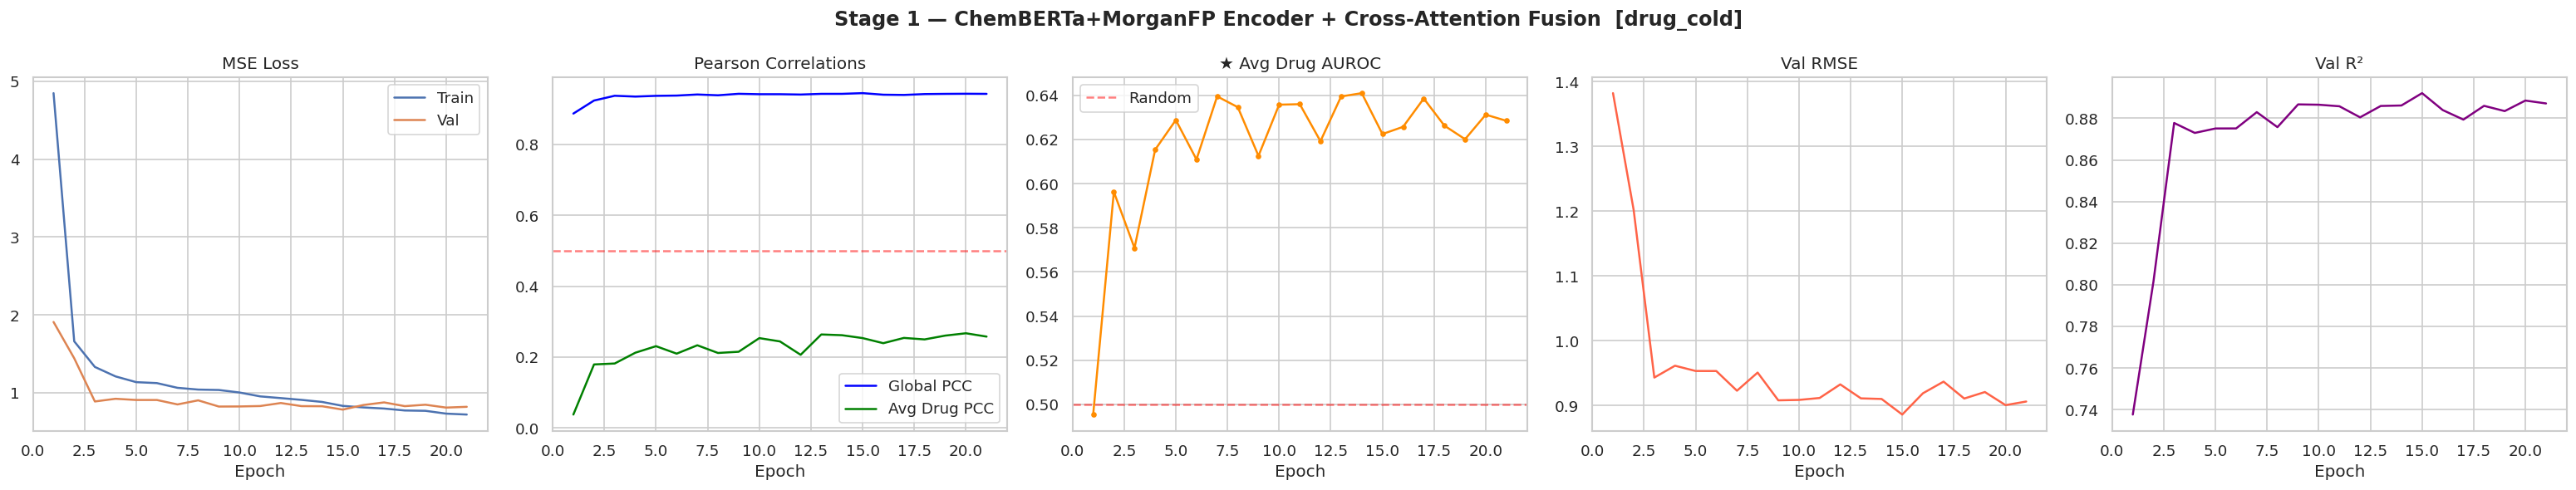

In [8]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 8 — STAGE 1 TRAINING
#  Head + cross-attention + ChemBERTa upper layers + Morgan projections.
#  Backbone remains fully frozen throughout Stage 1.
#
#  [C10] Checkpoints by CKPT_METRIC (GlobalPCC or avg_drug_auroc).
#  [C6]  run_epoch receives split_mode for ranking-loss activation.
# ═══════════════════════════════════════════════════════════════════════
section(f'8. STAGE 1 TRAINING ({CONFIG["stage1_epochs"]} epochs)  '
        f'[mode: {SPLIT_MODE} | ckpt: {CKPT_METRIC}]')

m = get_module(model)
trainable_s1 = [
    # ChemBERTa (encoder + all projection heads): lower LR as it is pretrained
    {'params': m.drug_encoder.parameters(),    'lr': CONFIG['stage1_lr'] * 0.1},
    # Drug-patient cross-attention fusion head
    {'params': m.fusion.parameters(),          'lr': CONFIG['stage1_lr']},
    # IC50 regression head
    {'params': m.regression_head.parameters(), 'lr': CONFIG['stage1_lr']},
]
opt_s1 = optim.AdamW(trainable_s1, weight_decay=CONFIG['stage1_wd'])

steps_per_epoch = math.ceil(len(train_loader) / CONFIG['grad_accum'])
total_steps_s1  = steps_per_epoch * CONFIG['stage1_epochs']

sched_s1 = optim.lr_scheduler.OneCycleLR(
    opt_s1,
    max_lr=[CONFIG['stage1_lr'] * 0.1,   # drug_encoder
            CONFIG['stage1_lr'],          # fusion
            CONFIG['stage1_lr']],         # regression_head
    total_steps=total_steps_s1,
    pct_start=CONFIG['warmup_frac'],
    anneal_strategy='cos',
    div_factor=10.0, final_div_factor=100.0)

scaler_s1 = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'])
best_s1   = -np.inf
patience_s1 = 0
hist_s1 = {k: [] for k in ['train_loss', 'val_loss', 'val_pcc',
                             'val_drug_pcc', 'val_auroc', 'val_rmse', 'val_r2']}

print(f'Steps/epoch : {steps_per_epoch} | Total steps : {total_steps_s1}')
print(f'Trainable   : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print()

for epoch in range(1, CONFIG['stage1_epochs'] + 1):
    t0 = time.time()

    tr_loss, tr_p, tr_t, tr_d = run_epoch(
        model, train_loader, opt_s1, scaler_s1, True,
        sched_s1, CONFIG['grad_accum'], split_mode=SPLIT_MODE)   # [C6]

    vl_loss, vl_p, vl_t, vl_d = run_epoch(
        model, val_loader, opt_s1, scaler_s1, False,
        split_mode=SPLIT_MODE)

    vm = compute_metrics(vl_p, vl_t, vl_d, id_to_drug)

    for k, v in zip(
        ['train_loss', 'val_loss', 'val_pcc', 'val_drug_pcc',
         'val_auroc', 'val_rmse', 'val_r2'],
        [tr_loss, vl_loss, vm['pearson'], vm['avg_drug_pearson'],
         vm['avg_drug_auroc'], vm['rmse'], vm['r2']]):
        hist_s1[k].append(v)

    auroc_str = (f'{vm["avg_drug_auroc"]:.4f}'
                 if not np.isnan(vm['avg_drug_auroc']) else '  N/A')
    print(f'[S1 {epoch:02d}/{CONFIG["stage1_epochs"]}]  '
          f'TrLoss={tr_loss:.4f}  VlLoss={vl_loss:.4f}  '
          f'PCC={vm["pearson"]:.4f}  DrugPCC={vm["avg_drug_pearson"]:.4f}  '
          f'AUROC={auroc_str}  RMSE={vm["rmse"]:.4f}  R2={vm["r2"]:.4f}  '
          f'{time.time()-t0:.0f}s')

    # [C10] Checkpoint by correct metric
    ckpt_val = get_ckpt_val(vm, SPLIT_MODE)
    if ckpt_val > best_s1:
        best_s1     = ckpt_val
        patience_s1 = 0
        torch.save(get_module(model).state_dict(), CONFIG['checkpoint_ft'])
        print(f'  ✓ Best saved  {CKPT_METRIC}={best_s1:.4f}  '
              f'DrugPCC={vm["avg_drug_pearson"]:.4f}  AUROC={auroc_str}')
    else:
        patience_s1 += 1
        if patience_s1 >= CONFIG['stage1_patience']:
            print(f'  Early stopping at epoch {epoch}')
            break

print(f'\nStage 1 complete.  Best {CKPT_METRIC} = {best_s1:.4f}')

E = range(1, len(hist_s1['train_loss']) + 1)
fig, axes = plt.subplots(1, 5, figsize=(26, 5))
fig.suptitle(f'Stage 1 — ChemBERTa+MorganFP Encoder + Cross-Attention Fusion  '
             f'[{SPLIT_MODE}]', fontweight='bold')
axes[0].plot(E, hist_s1['train_loss'], label='Train')
axes[0].plot(E, hist_s1['val_loss'],   label='Val')
axes[0].set_title('MSE Loss'); axes[0].legend()
axes[1].plot(E, hist_s1['val_pcc'],      label='Global PCC',   color='blue')
axes[1].plot(E, hist_s1['val_drug_pcc'], label='Avg Drug PCC', color='green')
axes[1].axhline(0.5, color='red', ls='--', alpha=0.5)
axes[1].set_title('Pearson Correlations'); axes[1].legend()
axes[2].plot(E, hist_s1['val_auroc'], color='darkorange', marker='.')
axes[2].axhline(0.5, color='red', ls='--', alpha=0.5, label='Random')
axes[2].set_title('★ Avg Drug AUROC'); axes[2].legend()
axes[3].plot(E, hist_s1['val_rmse'], color='tomato'); axes[3].set_title('Val RMSE')
axes[4].plot(E, hist_s1['val_r2'],   color='purple'); axes[4].set_title('Val R²')
for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}stage1_curves_{SPLIT_MODE}.png', dpi=150)
plt.show()


══════════════════════════════════════════════════════════════════════
  9. STAGE 2 TRAINING (30 epochs)  [mode: drug_cold | ckpt: avg_drug_auroc]
══════════════════════════════════════════════════════════════════════
[C4] Unfrozen last 2 transformer layers + norm of each modality encoder (104 parameter tensors).

Trainable modules (Stage 2):
  backbone.cross_layers                         TRAINABLE  28391424
  backbone.fusion                               TRAINABLE  6148
  backbone.*_enc (last 2 layers+norm)           TRAINABLE  14,198,784
  drug_encoder (trainable layers)               TRAINABLE  567936
  fusion (drug-patient)                         TRAINABLE  1825920
  regression_head                               TRAINABLE  148865

Total trainable Stage 2 : 45,139,077

[S2 01/30]  TrLoss=0.8178  VlLoss=0.7848  PCC=0.9448  DrugPCC=0.2833  AUROC=0.6392  RMSE=0.8859  R2=0.8922  122s
  ✓ Best saved  avg_drug_auroc=0.6392  DrugPCC=0.2833  AUROC=0.6392
[S2 02/30]  TrLoss=0.8022  VlLoss

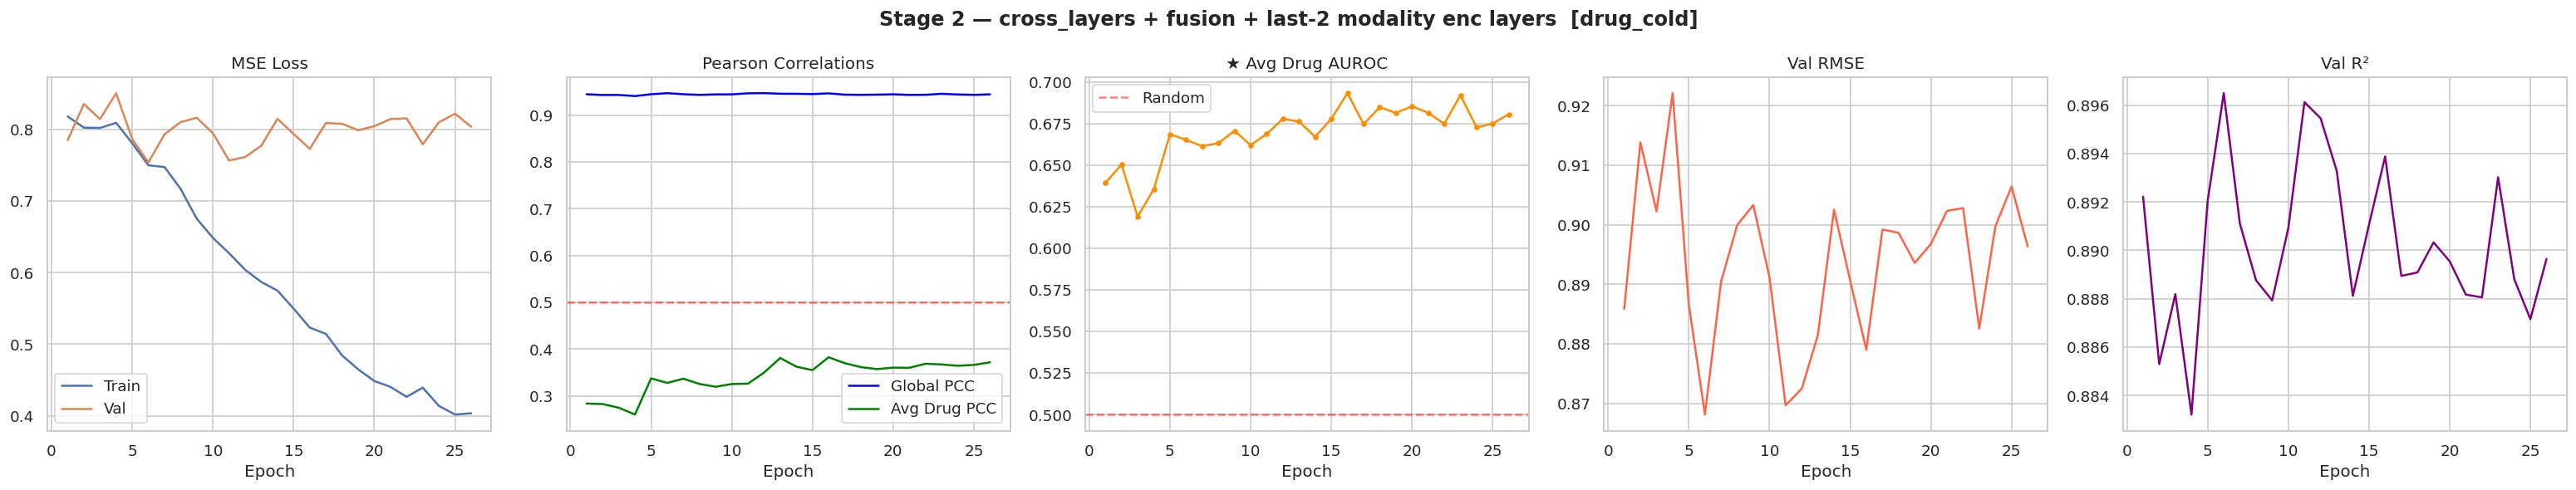

In [9]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 9 — STAGE 2 TRAINING
#
#  Loads Stage 1 best checkpoint, then unfreezes:
#    (a) backbone.cross_layers  (unchanged from v4)
#    (b) backbone.fusion        (unchanged from v4)
#    (c) [C4] Last `stage2_unfreeze_mod_layers` transformer layers + final
#             LayerNorm of each modality encoder (mrna_enc, cnv_enc,
#             mut_enc, meth_enc) with a very small LR (5e-6).
#
#  Rationale for C4:
#    The TCGA-pretrained modality encoders encode cancer-type identity.
#    The LAST 2 transformer layers capture higher-order feature composition
#    most amenable to domain adaptation.  Unfreezing them with LR 5e-6
#    (10× smaller than ChemBERTa) lets patient representations drift toward
#    drug-response-relevant features without destroying the broad cancer-type
#    structure that makes cell-cold work well.
#
#  Optimizer has 7 param groups; OneCycleLR takes 7 max_lr values.
#  [C10] Checkpoints by CKPT_METRIC.
# ═══════════════════════════════════════════════════════════════════════
section(f'9. STAGE 2 TRAINING ({CONFIG["stage2_epochs"]} epochs)  '
        f'[mode: {SPLIT_MODE} | ckpt: {CKPT_METRIC}]')

# Load Stage 1 best checkpoint
get_module(model).load_state_dict(
    torch.load(CONFIG['checkpoint_ft'], map_location=DEVICE))
get_module(model).freeze_backbone = False   # backbone now uses autograd

bm = get_module(model).backbone   # OncoBridgeMMCAT_v7

# Unfreeze backbone cross_layers + fusion (from v4)
for p in bm.cross_layers.parameters(): p.requires_grad = True
for p in bm.fusion.parameters():       p.requires_grad = True

# [C4] Unfreeze last N transformer layers + final LayerNorm of each modality encoder
N_UNFREEZE = CONFIG['stage2_unfreeze_mod_layers']
modality_enc_params = []

for enc_name in ['mrna_enc', 'cnv_enc', 'mut_enc', 'meth_enc']:
    enc      = getattr(bm, enc_name)
    n_layers = len(enc.transformer.layers)
    for i, layer in enumerate(enc.transformer.layers):
        if i >= n_layers - N_UNFREEZE:
            for p in layer.parameters():
                p.requires_grad = True
            modality_enc_params.extend(list(layer.parameters()))
    # Also unfreeze the final LayerNorm to allow scale/shift adaptation
    for p in enc.norm.parameters():
        p.requires_grad = True
    modality_enc_params.extend(list(enc.norm.parameters()))

print(f'[C4] Unfrozen last {N_UNFREEZE} transformer layers + norm of each '
      f'modality encoder ({len(modality_enc_params)} parameter tensors).')

# Deduplicate modality_enc_params (guard against shared params)
seen_ids = set()
unique_mod_params = []
for p in modality_enc_params:
    pid = id(p)
    if pid not in seen_ids:
        seen_ids.add(pid)
        unique_mod_params.append(p)

# ── Summary of trainable modules ─────────────────────────────────────
print('\nTrainable modules (Stage 2):')
m_mod = get_module(model)
modules_s2 = {
    'backbone.cross_layers':           bm.cross_layers,
    'backbone.fusion':                 bm.fusion,
    f'backbone.*_enc (last {N_UNFREEZE} layers+norm)': None,  # shown below
    'drug_encoder (trainable layers)': m_mod.drug_encoder,
    'fusion (drug-patient)':           m_mod.fusion,
    'regression_head':                 m_mod.regression_head,
}
for name, mod in modules_s2.items():
    if mod is None:
        n_tr = sum(p.numel() for p in unique_mod_params)
        print(f'  {name:<45} TRAINABLE  {n_tr:,}')
    else:
        n_tr = sum(p.numel() for p in mod.parameters() if p.requires_grad)
        print(f'  {name:<45} '
              f'{"TRAINABLE  " + str(n_tr) if n_tr else "FROZEN"}')

# ── Optimizer (7 param groups) ────────────────────────────────────────
m = get_module(model)
opt_s2 = optim.AdamW([
    # Group 0: regression head
    {'params': list(m.regression_head.parameters()),
     'lr': CONFIG['stage2_lr_head']},
    # Group 1: drug-patient cross-attention fusion
    {'params': list(m.fusion.parameters()),
     'lr': CONFIG['stage2_lr_head']},
    # Group 2: backbone cross-modal attention layers
    {'params': list(bm.cross_layers.parameters()),
     'lr': CONFIG['stage2_lr_cross']},
    # Group 3: backbone gated fusion
    {'params': list(bm.fusion.parameters()),
     'lr': CONFIG['stage2_lr_cross']},
    # Group 4: trainable ChemBERTa transformer layers
    {'params': [p for p in m.drug_encoder.encoder.parameters()
                if p.requires_grad],
     'lr': CONFIG['stage2_lr_cbert']},
    # Group 5: drug encoder projection heads (smiles_proj + morgan_proj + fusion_proj)
    {'params': (list(m.drug_encoder.smiles_proj.parameters()) +
                list(m.drug_encoder.morgan_proj.parameters()) +
                list(m.drug_encoder.fusion_proj.parameters())),
     'lr': CONFIG['stage2_lr_proj']},
    # Group 6: [C4] last N layers + norm of each modality encoder
    {'params': unique_mod_params,
     'lr': CONFIG['stage2_lr_mod_enc']},
], weight_decay=CONFIG['stage2_wd'])

total_steps_s2 = (math.ceil(len(train_loader) / CONFIG['grad_accum'])
                  * CONFIG['stage2_epochs'])

sched_s2 = optim.lr_scheduler.OneCycleLR(
    opt_s2,
    max_lr=[
        CONFIG['stage2_lr_head'],     # regression_head
        CONFIG['stage2_lr_head'],     # fusion (drug-patient)
        CONFIG['stage2_lr_cross'],    # backbone.cross_layers
        CONFIG['stage2_lr_cross'],    # backbone.fusion
        CONFIG['stage2_lr_cbert'],    # drug_encoder.encoder (trainable)
        CONFIG['stage2_lr_proj'],     # drug_encoder projection heads
        CONFIG['stage2_lr_mod_enc'],  # [C4] modality enc last layers
    ],
    total_steps=total_steps_s2,
    pct_start=CONFIG['warmup_frac'],
    anneal_strategy='cos',
    div_factor=10.0, final_div_factor=100.0)

scaler_s2 = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'])
best_s2    = -np.inf
patience_s2 = 0
hist_s2 = {k: [] for k in ['train_loss', 'val_loss', 'val_pcc',
                             'val_drug_pcc', 'val_auroc', 'val_rmse', 'val_r2']}

n_tr_s2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable Stage 2 : {n_tr_s2:,}')
print()

for epoch in range(1, CONFIG['stage2_epochs'] + 1):
    t0 = time.time()

    tr_loss, tr_p, tr_t, tr_d = run_epoch(
        model, train_loader, opt_s2, scaler_s2, True,
        sched_s2, CONFIG['grad_accum'], split_mode=SPLIT_MODE)   # [C6]

    vl_loss, vl_p, vl_t, vl_d = run_epoch(
        model, val_loader, opt_s2, scaler_s2, False,
        split_mode=SPLIT_MODE)

    vm = compute_metrics(vl_p, vl_t, vl_d, id_to_drug)

    for k, v in zip(
        ['train_loss', 'val_loss', 'val_pcc', 'val_drug_pcc',
         'val_auroc', 'val_rmse', 'val_r2'],
        [tr_loss, vl_loss, vm['pearson'], vm['avg_drug_pearson'],
         vm['avg_drug_auroc'], vm['rmse'], vm['r2']]):
        hist_s2[k].append(v)

    auroc_str = (f'{vm["avg_drug_auroc"]:.4f}'
                 if not np.isnan(vm['avg_drug_auroc']) else '  N/A')
    print(f'[S2 {epoch:02d}/{CONFIG["stage2_epochs"]}]  '
          f'TrLoss={tr_loss:.4f}  VlLoss={vl_loss:.4f}  '
          f'PCC={vm["pearson"]:.4f}  DrugPCC={vm["avg_drug_pearson"]:.4f}  '
          f'AUROC={auroc_str}  RMSE={vm["rmse"]:.4f}  R2={vm["r2"]:.4f}  '
          f'{time.time()-t0:.0f}s')

    # [C10] Checkpoint by correct metric
    ckpt_val = get_ckpt_val(vm, SPLIT_MODE)
    if ckpt_val > best_s2:
        best_s2     = ckpt_val
        patience_s2 = 0
        torch.save(get_module(model).state_dict(), CONFIG['checkpoint_ft'])
        print(f'  ✓ Best saved  {CKPT_METRIC}={best_s2:.4f}  '
              f'DrugPCC={vm["avg_drug_pearson"]:.4f}  AUROC={auroc_str}')
    else:
        patience_s2 += 1
        if patience_s2 >= CONFIG['stage2_patience']:
            print(f'  Early stopping at epoch {epoch}')
            break

print(f'\nStage 2 complete.  Best {CKPT_METRIC} = {best_s2:.4f}')

E = range(1, len(hist_s2['train_loss']) + 1)
fig, axes = plt.subplots(1, 5, figsize=(26, 5))
fig.suptitle(f'Stage 2 — cross_layers + fusion + last-{N_UNFREEZE} modality enc layers  '
             f'[{SPLIT_MODE}]', fontweight='bold')
axes[0].plot(E, hist_s2['train_loss'], label='Train')
axes[0].plot(E, hist_s2['val_loss'],   label='Val')
axes[0].set_title('MSE Loss'); axes[0].legend()
axes[1].plot(E, hist_s2['val_pcc'],      label='Global PCC',   color='blue')
axes[1].plot(E, hist_s2['val_drug_pcc'], label='Avg Drug PCC', color='green')
axes[1].axhline(0.5, color='red', ls='--', alpha=0.5)
axes[1].set_title('Pearson Correlations'); axes[1].legend()
axes[2].plot(E, hist_s2['val_auroc'], color='darkorange', marker='.')
axes[2].axhline(0.5, color='red', ls='--', alpha=0.5, label='Random')
axes[2].set_title('★ Avg Drug AUROC'); axes[2].legend()
axes[3].plot(E, hist_s2['val_rmse'], color='tomato'); axes[3].set_title('Val RMSE')
axes[4].plot(E, hist_s2['val_r2'],   color='purple'); axes[4].set_title('Val R²')
for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}stage2_curves_{SPLIT_MODE}.png', dpi=150)
plt.show()


══════════════════════════════════════════════════════════════════════
  10. EVALUATION — DRUG_COLD TEST SET
══════════════════════════════════════════════════════════════════════
Best checkpoint loaded.

  DRUG_COLD TEST SET  (raw model)
  Pearson PCC         : 0.2245
  Spearman SCC        : 0.1098
  RMSE                : 2.3889
  R²                  : -0.1357
  ─── Per-drug (drugs ≥5 samples : 11) ───
  Avg Drug Pearson    : 0.2439
  Avg Drug Spearman   : 0.2944
  ★ Avg Drug AUROC    : 0.6569
    (AUROC valid drugs: 11)

─────────────────────────────────────────────────────────────────
[C9] Applying Tanimoto Ensemble...

[C9] Tanimoto Ensemble — 11 test drugs × 63 train drugs
  Similarity matrix : (11, 63)  max=0.531  mean=0.118
  threshold=0.2  top_k=5  blend_weight=0.4
  AZD7762              → ['NIRAPARIB', 'GSK2110183', 'TRAMETINIB']  sims=[0.275 0.244 0.227]
  [skip] MIRIN: no training drugs above threshold (max_sim=0.186)
  [skip] OXALIPLATIN: no training drugs above threshold 

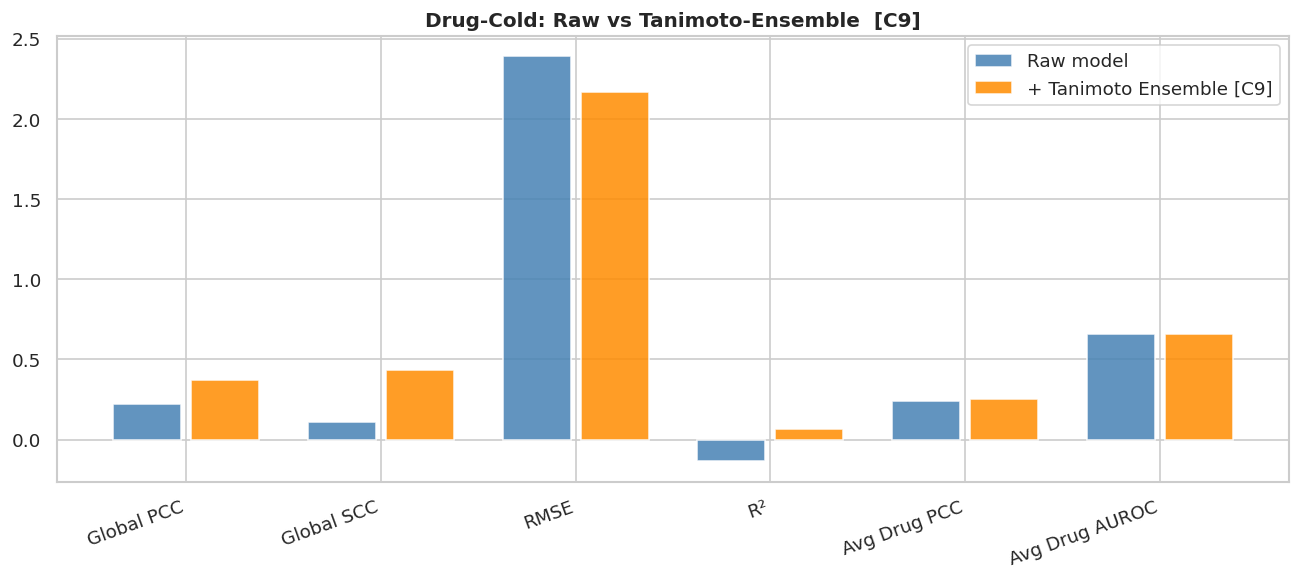

In [10]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 10 — EVALUATION ON TEST SET  (SPLIT_MODE)
#
#  [C9] For drug-cold:  after raw model evaluation, applies Tanimoto-
#       similarity ensemble to blend cold-drug predictions with predictions
#       for structurally similar training drugs.  Both raw and blended
#       metrics are reported, and te_preds / te_results are updated to the
#       blended version so all downstream cells (11–16) use it.
#
#  Tanimoto ensemble rationale (C9):
#    Each cold test drug X is structurally similar to some training drugs
#    {Y₁,...,Yₖ} (measured by Tanimoto on ECFP4 fingerprints).  The model
#    has well-calibrated predictions for Yᵢ on all cell lines.  Since X and
#    Yᵢ share substructures they likely share mechanism-of-action, so blending
#    model(cell, X) with Σwᵢ·model(cell,Yᵢ) is a principled way to borrow
#    strength from trained drugs.
#
#  Blend formula:
#    pred_blended(c, X) = (1 - w) · model(c, X)
#                       + w · Σᵢ [Tanimoto(X,Yᵢ)/ΣTanimoto(X,Yⱼ)] · model(c,Yᵢ)
#    where w = CONFIG['tanimoto_blend_weight'] = 0.4
#    and only Yᵢ with Tanimoto ≥ CONFIG['tanimoto_threshold'] = 0.2 are used.
# ═══════════════════════════════════════════════════════════════════════
section(f'10. EVALUATION — {SPLIT_MODE.upper()} TEST SET')

# ── Load best checkpoint ──────────────────────────────────────────────
get_module(model).load_state_dict(
    torch.load(CONFIG['checkpoint_ft'], map_location=DEVICE))
model.eval()
print('Best checkpoint loaded.')

# ── Raw model evaluation ──────────────────────────────────────────────
_, te_preds, te_targets, te_drug_ids = run_epoch(
    model, test_loader, None, None, is_train=False,
    split_mode=SPLIT_MODE)

te_results = compute_metrics(te_preds, te_targets, te_drug_ids, id_to_drug)
auroc_str  = (f'{te_results["avg_drug_auroc"]:.4f}'
              if not np.isnan(te_results['avg_drug_auroc']) else '  N/A ')

print(f'\n{"="*65}')
print(f'  {SPLIT_MODE.upper()} TEST SET  (raw model)')
print(f'{"="*65}')
print(f'  Pearson PCC         : {te_results["pearson"]:.4f}')
print(f'  Spearman SCC        : {te_results["spearman"]:.4f}')
print(f'  RMSE                : {te_results["rmse"]:.4f}')
print(f'  R²                  : {te_results["r2"]:.4f}')
print(f'  ─── Per-drug (drugs ≥5 samples : {te_results["n_drugs_evaluated"]}) ───')
print(f'  Avg Drug Pearson    : {te_results["avg_drug_pearson"]:.4f}')
print(f'  Avg Drug Spearman   : {te_results["avg_drug_spearman"]:.4f}')
print(f'  ★ Avg Drug AUROC    : {auroc_str}')
print(f'    (AUROC valid drugs: {te_results["n_drugs_auroc_valid"]})')


# ── [C9] Tanimoto similarity ensemble (drug-cold only) ───────────────

def _tanimoto_matrix(fps_a: np.ndarray, fps_b: np.ndarray) -> np.ndarray:
    """
    Vectorised Tanimoto similarity between two float32 fingerprint matrices.
    Handles both binary (0/1) and real-valued (count) ECFP fingerprints.

    T(a, b) = (a · b) / (||a||² + ||b||² - a · b)

    Args:
        fps_a : (m, d)
        fps_b : (n, d)
    Returns:
        sim   : (m, n)
    """
    fps_a = fps_a.astype(np.float64)
    fps_b = fps_b.astype(np.float64)
    dot   = fps_a @ fps_b.T                                  # (m, n)
    na    = np.sum(fps_a ** 2, axis=1, keepdims=True)        # (m, 1)
    nb    = np.sum(fps_b ** 2, axis=1, keepdims=True)        # (n, 1)
    denom = na + nb.T - dot                                  # (m, n)
    denom = np.maximum(denom, 1e-9)
    return (dot / denom).astype(np.float32)


def run_tanimoto_ensemble(
    model, tokenizer,
    ic50_test, ic50_train,
    mrna_arr, cnv_arr, mut_arr, meth_arr,
    smiles_map, morgan_fp_matrix, drug_to_morgan_idx,
    te_preds: np.ndarray,
    device, cfg
) -> np.ndarray:
    """
    Tanimoto-weighted ensemble for drug-cold predictions.

    For each cold test drug X:
      1. Compute Tanimoto similarity to all training drugs on ECFP4 FPs.
      2. Select top-k training drugs with sim ≥ threshold.
      3. Run batch inference for (test_cell_lines, similar_drug) pairs.
      4. Blend: (1-w) · raw_pred + w · weighted_avg_similar_preds.

    Returns blended prediction array (same shape as te_preds).
    """
    top_k        = cfg['tanimoto_top_k']
    threshold    = cfg['tanimoto_threshold']
    blend_weight = cfg['tanimoto_blend_weight']
    max_len      = cfg['chemberta_max_len']
    INFER_BS     = 128

    m_mod = get_module(model)
    m_mod.eval()

    test_drug_names  = ic50_test['DRUG_NAME'].values
    unique_test_drugs = ic50_test['DRUG_NAME'].unique().tolist()
    train_drug_names  = sorted(ic50_train['DRUG_NAME'].unique().tolist())

    # Filter to drugs with known Morgan FPs
    test_drugs_fp  = [d for d in unique_test_drugs if d in drug_to_morgan_idx]
    train_drugs_fp = [d for d in train_drug_names  if d in drug_to_morgan_idx]

    if not test_drugs_fp or not train_drugs_fp:
        print('  [C9 skip] No Morgan FP coverage for test or train drugs.')
        return te_preds.copy()

    # Tanimoto similarity matrix  (n_test × n_train)
    test_fps  = morgan_fp_matrix[[drug_to_morgan_idx[d] for d in test_drugs_fp]]
    train_fps = morgan_fp_matrix[[drug_to_morgan_idx[d] for d in train_drugs_fp]]
    sim_mat   = _tanimoto_matrix(test_fps, train_fps)

    print(f'\n[C9] Tanimoto Ensemble — '
          f'{len(test_drugs_fp)} test drugs × {len(train_drugs_fp)} train drugs')
    print(f'  Similarity matrix : {sim_mat.shape}  '
          f'max={sim_mat.max():.3f}  mean={sim_mat[sim_mat > 0].mean():.3f}')
    print(f'  threshold={threshold}  top_k={top_k}  blend_weight={blend_weight}')

    blended_preds = te_preds.copy()
    cl_idx_col    = ic50_test['cl_idx'].values.astype(int)
    n_blended     = 0

    for ti, cold_drug in enumerate(test_drugs_fp):
        sim_row = sim_mat[ti]                   # (n_train,)
        above   = sim_row >= threshold

        if not above.any():
            print(f'  [skip] {cold_drug}: no training drugs above threshold '
                  f'(max_sim={sim_row.max():.3f})')
            continue

        # Select top-k, sorted by similarity
        cand_idx   = np.where(above)[0]
        sorted_sub = cand_idx[np.argsort(sim_row[cand_idx])[::-1]]
        top_idx    = sorted_sub[:top_k]
        top_sims   = sim_row[top_idx]
        top_drugs  = [train_drugs_fp[j] for j in top_idx]
        sim_weights = top_sims / top_sims.sum()

        print(f'  {cold_drug:<20} → {top_drugs}  '
              f'sims={top_sims.round(3)}')

        # Find test-set row indices for this cold drug
        cold_mask    = (test_drug_names == cold_drug)
        cold_cl_idxs = cl_idx_col[cold_mask]    # cell line array indices

        # Accumulate weighted predictions over similar training drugs
        ensemble_pred = np.zeros(cold_mask.sum(), dtype=np.float64)

        for tr_drug, w in zip(top_drugs, sim_weights):
            smiles = smiles_map.get(tr_drug, 'C') or 'C'
            enc    = tokenizer(smiles, max_length=max_len,
                               padding='max_length', truncation=True,
                               return_tensors='pt')
            ids_1  = enc['input_ids'].to(device)          # (1, L)
            mask_1 = enc['attention_mask'].to(device)     # (1, L)
            fp_idx = drug_to_morgan_idx[tr_drug]
            fp_1   = torch.from_numpy(
                morgan_fp_matrix[fp_idx]).float().unsqueeze(0).to(device)  # (1, D)

            drug_preds = []
            for start in range(0, len(cold_cl_idxs), INFER_BS):
                batch_cl = cold_cl_idxs[start: start + INFER_BS]
                B        = len(batch_cl)
                mrna_b = torch.from_numpy(mrna_arr[batch_cl]).to(device)
                cnv_b  = torch.from_numpy(cnv_arr[batch_cl]).to(device)
                mut_b  = torch.from_numpy(mut_arr[batch_cl]).to(device)
                meth_b = torch.from_numpy(meth_arr[batch_cl]).to(device)
                ids_b  = ids_1.expand(B, -1)
                mask_b = mask_1.expand(B, -1)
                fp_b   = fp_1.expand(B, -1)
                with torch.no_grad():
                    p = m_mod(mrna_b, cnv_b, mut_b, meth_b,
                              ids_b, mask_b, fp_b).squeeze(1)
                drug_preds.append(p.cpu().numpy())

            ensemble_pred += float(w) * np.concatenate(drug_preds)

        # Blend raw and ensemble predictions
        blended_preds[cold_mask] = (
            (1.0 - blend_weight) * te_preds[cold_mask] +
            blend_weight         * ensemble_pred
        )
        n_blended += 1

    print(f'\n  Blended {n_blended} / {len(test_drugs_fp)} test drugs')
    return blended_preds


if SPLIT_MODE == 'drug_cold':
    print('\n' + '─'*65)
    print('[C9] Applying Tanimoto Ensemble...')
    te_preds_raw = te_preds.copy()

    te_preds = run_tanimoto_ensemble(
        model, tokenizer,
        ic50_test, ic50_train,
        mrna_arr, cnv_arr, mut_arr, meth_arr,
        smiles_map, morgan_fp_matrix, drug_to_morgan_idx,
        te_preds_raw, DEVICE, CONFIG)

    te_results = compute_metrics(te_preds, te_targets, te_drug_ids, id_to_drug)
    auroc_blended = (f'{te_results["avg_drug_auroc"]:.4f}'
                     if not np.isnan(te_results['avg_drug_auroc']) else '  N/A ')

    print(f'\n{"="*65}')
    print(f'  {SPLIT_MODE.upper()} TEST SET  (after Tanimoto Ensemble  [C9])')
    print(f'{"="*65}')
    print(f'  Pearson PCC         : {te_results["pearson"]:.4f}')
    print(f'  Spearman SCC        : {te_results["spearman"]:.4f}')
    print(f'  RMSE                : {te_results["rmse"]:.4f}')
    print(f'  R²                  : {te_results["r2"]:.4f}')
    print(f'  ─── Per-drug (drugs ≥5 samples : {te_results["n_drugs_evaluated"]}) ───')
    print(f'  Avg Drug Pearson    : {te_results["avg_drug_pearson"]:.4f}')
    print(f'  Avg Drug Spearman   : {te_results["avg_drug_spearman"]:.4f}')
    print(f'  ★ Avg Drug AUROC    : {auroc_blended}')
    print(f'    (AUROC valid drugs: {te_results["n_drugs_auroc_valid"]})')
    print('  [te_preds and te_results updated to blended version for downstream cells]')

    # ── Side-by-side delta plot ──────────────────────────────────────
    raw_results = compute_metrics(te_preds_raw, te_targets, te_drug_ids, id_to_drug)
    metrics_compare = ['pearson', 'spearman', 'rmse', 'r2',
                        'avg_drug_pearson', 'avg_drug_auroc']
    labels = ['Global PCC', 'Global SCC', 'RMSE', 'R²',
              'Avg Drug PCC', 'Avg Drug AUROC']
    raw_vals    = [raw_results.get(k, 0) or 0 for k in metrics_compare]
    blended_vals = [te_results.get(k, 0) or 0  for k in metrics_compare]

    x = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(x - 0.2, raw_vals,     0.35, label='Raw model', color='steelblue',   alpha=0.85)
    ax.bar(x + 0.2, blended_vals, 0.35, label='+ Tanimoto Ensemble [C9]',
           color='darkorange', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_title(f'Drug-Cold: Raw vs Tanimoto-Ensemble  [C9]', fontweight='bold')
    ax.legend(); plt.tight_layout()
    plt.savefig(f'{OUT_DIR}tanimoto_comparison_{SPLIT_MODE}.png', dpi=150)
    plt.show()
else:
    print(f'\n[C9] Tanimoto ensemble skipped (not drug-cold mode).')

In [11]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 11 — SOTA COMPARISON
# ═══════════════════════════════════════════════════════════════════════
section('11. SOTA COMPARISON')

SOTA = [
    ('DTCDR [1]',    0.949, 0.867, 0.621, 0.820, 'GDSC2; mRNA+Mut+CNV'),
    ('PASO [2]',     0.941, 0.887, 0.614, None,  'GDSC2; multi-omics'),
    ('TGSA [3]',     0.920, 0.821, 0.560, None,  'GDSC2; graph drug'),
    ('DeepCDR [4]',  0.921, 0.792, None,  None,  'GDSC2; GCN drug'),
    ('GraphDRP [5]', 0.912, 0.774, None,  None,  'GDSC2; graph drug'),
    ('MOLI [6]',     0.853, 0.713, None,  None,  'GDSC2; triplet loss'),
    ('CDRscan [7]',  0.801, None,  None,  None,  'GDSC2; CNN drug'),
]

_split_col = {'warm': 1, 'cell_cold': 2, 'drug_cold': 3}[SPLIT_MODE]
our_pcc    = te_results['pearson']
our_auroc  = te_results['avg_drug_auroc'] if not np.isnan(te_results['avg_drug_auroc']) else None

suffix = ' (+Tanimoto)' if SPLIT_MODE == 'drug_cold' else ''
ob_entry = (
    f'OncoBridge v5{suffix} (Ours)',
    our_pcc if SPLIT_MODE == 'warm'       else None,
    our_pcc if SPLIT_MODE == 'cell_cold'  else None,
    our_pcc if SPLIT_MODE == 'drug_cold'  else None,
    our_auroc if SPLIT_MODE == 'warm'     else None,
    f'GDSC2; ChemBERTa+MorganFP·CrossAttn [{SPLIT_MODE}]',
)
SOTA_FULL = [ob_entry] + SOTA

def fmt(v): return f'{v:.3f}' if v is not None else '  N/R '

W = 100
print(f'\n  Active split: {SPLIT_MODE.upper()}')
print(f'{"═"*W}')
print(f'  {"Model":<32} {"Warm PCC":>10} {"CellCold":>10} '
      f'{"DrugCold":>10} {"AUROC(W)":>10}  Notes')
print(f'  {"-"*(W-2)}')
for i, (name, pcc_w, pcc_cc, pcc_dc, auroc_w, note) in enumerate(SOTA_FULL):
    marker = ' ◀ OUR MODEL' if i == 0 else ''
    print(f'  {name:<32} {fmt(pcc_w):>10} {fmt(pcc_cc):>10} '
          f'{fmt(pcc_dc):>10} {fmt(auroc_w):>10}  {note}{marker}')
print(f'{"═"*W}')

dtcdr_val = SOTA[0][_split_col]
if dtcdr_val is not None:
    delta = our_pcc - dtcdr_val
    split_label = SPLIT_MODE.replace('_', '-').title()
    print(f'\n  Δ vs DTCDR [{split_label} PCC]  : {our_pcc:.4f}  '
          f'(DTCDR {dtcdr_val:.3f})  Δ = {delta:+.4f}')

if SPLIT_MODE == 'warm' and our_auroc is not None:
    dtcdr_auroc = 0.820
    print(f'  Δ vs DTCDR [Warm AUROC]      : {our_auroc:.4f}  '
          f'(DTCDR {dtcdr_auroc:.3f})  Δ = {our_auroc - dtcdr_auroc:+.4f}')

rows = [{
    'split':             SPLIT_MODE,
    'tanimoto_applied':  SPLIT_MODE == 'drug_cold',
    'pearson':           round(te_results['pearson'],          4),
    'spearman':          round(te_results['spearman'],         4),
    'rmse':              round(te_results['rmse'],             4),
    'r2':                round(te_results['r2'],               4),
    'avg_drug_pearson':  round(te_results['avg_drug_pearson'], 4),
    'avg_drug_spearman': round(te_results['avg_drug_spearman'],4),
    'avg_drug_auroc':    (round(te_results['avg_drug_auroc'], 4)
                          if not np.isnan(te_results['avg_drug_auroc']) else None),
    'n_drugs_evaluated': te_results['n_drugs_evaluated'],
}]
summary_df = pd.DataFrame(rows)
summary_df.to_csv(f'{OUT_DIR}evaluation_summary_{SPLIT_MODE}.csv', index=False)
print(f'\nSaved: evaluation_summary_{SPLIT_MODE}.csv')


══════════════════════════════════════════════════════════════════════
  11. SOTA COMPARISON
══════════════════════════════════════════════════════════════════════

  Active split: DRUG_COLD
════════════════════════════════════════════════════════════════════════════════════════════════════
  Model                              Warm PCC   CellCold   DrugCold   AUROC(W)  Notes
  --------------------------------------------------------------------------------------------------
  OncoBridge v5 (+Tanimoto) (Ours)       N/R        N/R       0.374       N/R   GDSC2; ChemBERTa+MorganFP·CrossAttn [drug_cold] ◀ OUR MODEL
  DTCDR [1]                             0.949      0.867      0.621      0.820  GDSC2; mRNA+Mut+CNV
  PASO [2]                              0.941      0.887      0.614       N/R   GDSC2; multi-omics
  TGSA [3]                              0.920      0.821      0.560       N/R   GDSC2; graph drug
  DeepCDR [4]                           0.921      0.792       N/R        N/R   GDS


══════════════════════════════════════════════════════════════════════
  12. VISUALISATIONS
══════════════════════════════════════════════════════════════════════


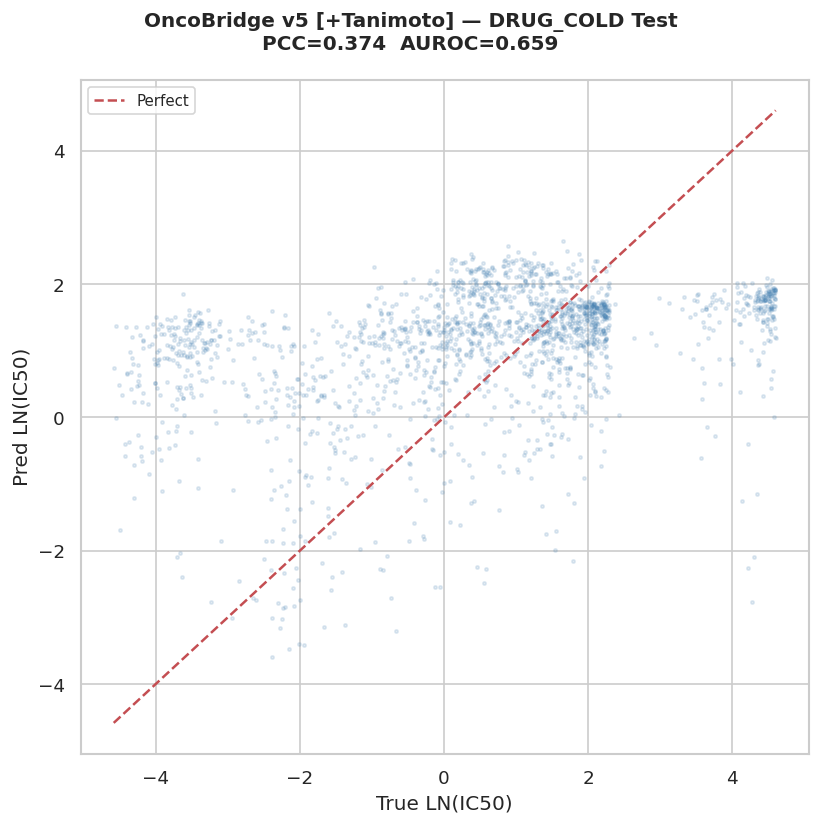

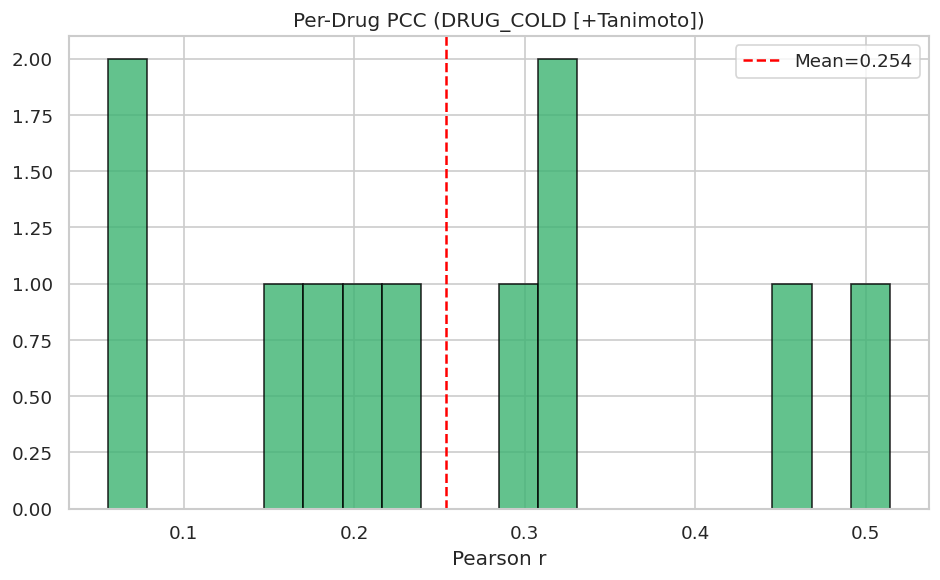

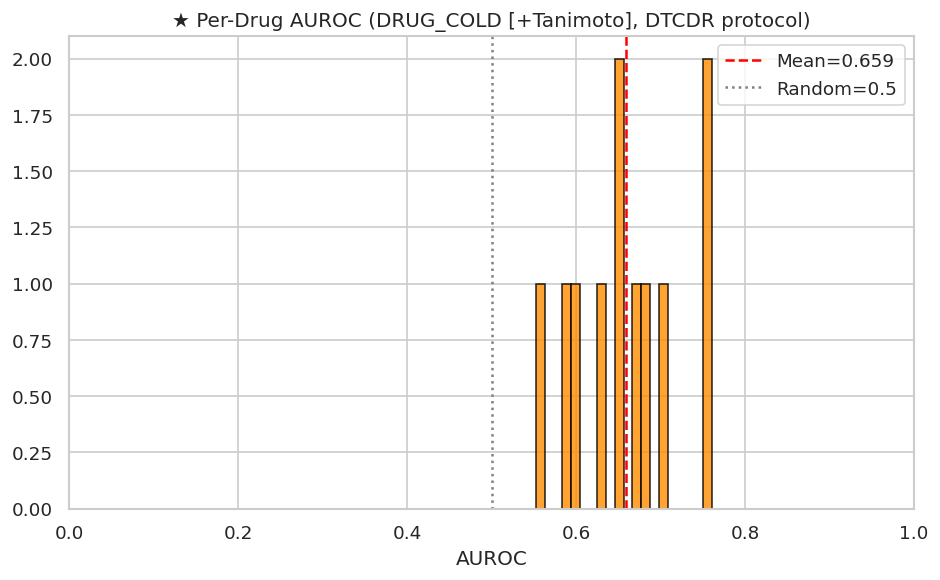

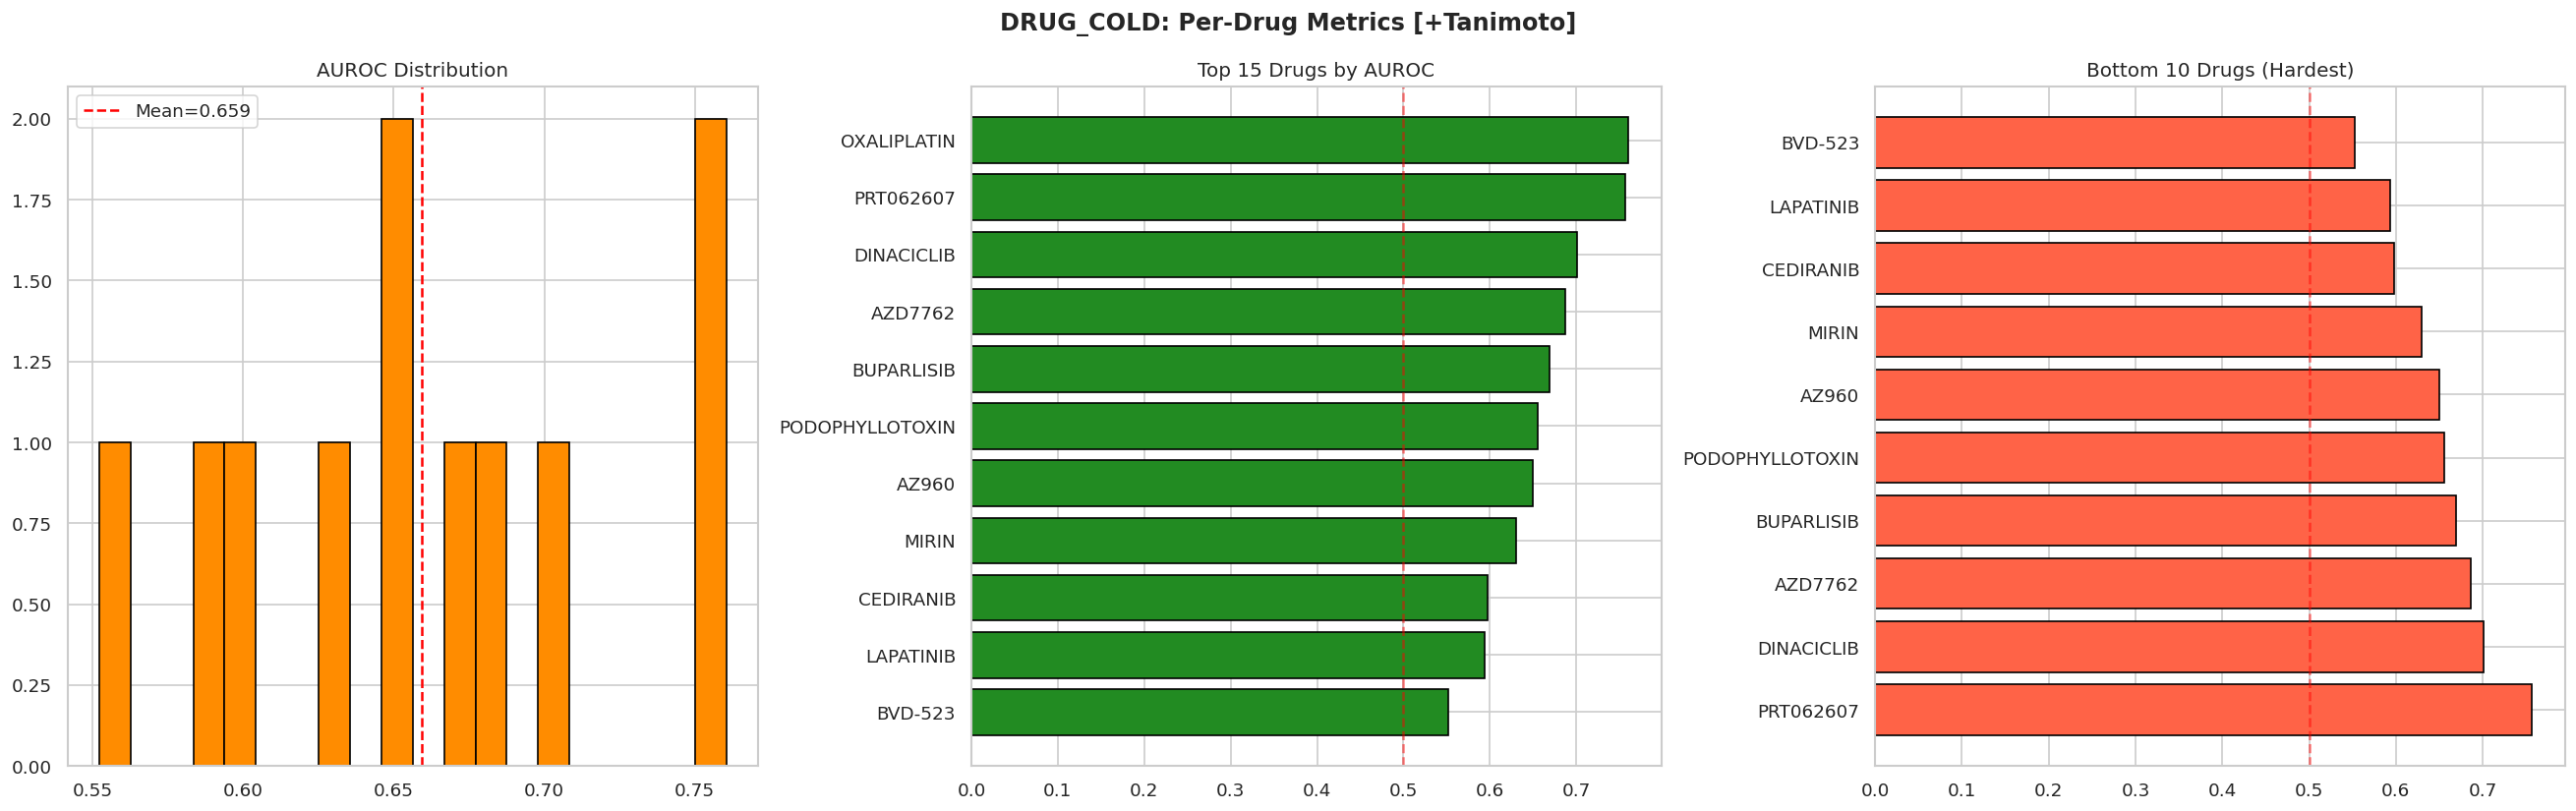

Saved: per_drug_metrics_drug_cold.csv  (11 drugs)

Top 20 drugs (DRUG_COLD, sorted by AUROC):
                 pearson   auroc  n_samples
OXALIPLATIN       0.5141  0.7604       48.0
PRT062607         0.4604  0.7569       72.0
DINACICLIB        0.2214  0.7010      242.0
AZD7762           0.3160  0.6868      303.0
BUPARLISIB        0.2976  0.6689      284.0
PODOPHYLLOTOXIN   0.3086  0.6558      170.0
AZ960             0.2005  0.6497      107.0
MIRIN             0.1677  0.6301      208.0
CEDIRANIB         0.1862  0.5979      261.0
LAPATINIB         0.0556  0.5936      116.0
BVD-523           0.0625  0.5523       78.0

Bottom 10 drugs (DRUG_COLD, lowest AUROC):
                 pearson   auroc  n_samples
PRT062607         0.4604  0.7569       72.0
DINACICLIB        0.2214  0.7010      242.0
AZD7762           0.3160  0.6868      303.0
BUPARLISIB        0.2976  0.6689      284.0
PODOPHYLLOTOXIN   0.3086  0.6558      170.0
AZ960             0.2005  0.6497      107.0
MIRIN             0.1677  

In [12]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 12 — VISUALISATIONS  (active SPLIT_MODE test set)
# ═══════════════════════════════════════════════════════════════════════
section('12. VISUALISATIONS')

auroc_val = te_results['avg_drug_auroc']
auroc_str = f'{auroc_val:.3f}' if not np.isnan(auroc_val) else 'N/A'
suffix    = ' [+Tanimoto]' if SPLIT_MODE == 'drug_cold' else ''

# ── 1. Scatter: true vs predicted ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
fig.suptitle(f'OncoBridge v5{suffix} — {SPLIT_MODE.upper()} Test\n'
             f'PCC={te_results["pearson"]:.3f}  AUROC={auroc_str}',
             fontweight='bold', fontsize=12)
ax.scatter(te_targets, te_preds, alpha=0.15, s=4, c='steelblue', rasterized=True)
mn = min(te_targets.min(), te_preds.min())
mx = max(te_targets.max(), te_preds.max())
ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect')
ax.set_xlabel('True LN(IC50)'); ax.set_ylabel('Pred LN(IC50)')
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig(f'{OUT_DIR}scatter_{SPLIT_MODE}.png', dpi=150)
plt.show()

# ── 2. Per-Drug PCC distribution ──────────────────────────────────────
drug_pccs = [v['pearson'] for v in te_results['per_drug'].values()]
fig, ax   = plt.subplots(figsize=(8, 5))
ax.hist(drug_pccs, bins=20, color='mediumseagreen', edgecolor='black', alpha=0.8)
ax.axvline(np.mean(drug_pccs), color='red', ls='--',
           label=f'Mean={np.mean(drug_pccs):.3f}')
ax.set_title(f'Per-Drug PCC ({SPLIT_MODE.upper()}{suffix})')
ax.set_xlabel('Pearson r'); ax.legend(); plt.tight_layout()
plt.savefig(f'{OUT_DIR}per_drug_pcc_dist_{SPLIT_MODE}.png', dpi=150)
plt.show()

# ── 3. Per-Drug AUROC distribution ────────────────────────────────────
auroc_vals = [v['auroc'] for v in te_results['per_drug'].values()
              if not np.isnan(v['auroc'])]
mean_auc   = np.mean(auroc_vals) if auroc_vals else 0.0
fig, ax    = plt.subplots(figsize=(8, 5))
ax.hist(auroc_vals, bins=20, color='darkorange', edgecolor='black', alpha=0.8)
ax.axvline(mean_auc, color='red', ls='--', label=f'Mean={mean_auc:.3f}')
ax.axvline(0.5, color='grey', ls=':', label='Random=0.5')
ax.set_title(f'★ Per-Drug AUROC ({SPLIT_MODE.upper()}{suffix}, DTCDR protocol)')
ax.set_xlabel('AUROC'); ax.set_xlim(0, 1); ax.legend(); plt.tight_layout()
plt.savefig(f'{OUT_DIR}per_drug_auroc_dist_{SPLIT_MODE}.png', dpi=150)
plt.show()

# ── 4. Top / Bottom drugs by AUROC ────────────────────────────────────
drug_df = pd.DataFrame(te_results['per_drug']).T
drug_df = drug_df[drug_df['auroc'].notna()].copy()
drug_df = drug_df.sort_values('auroc', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(f'{SPLIT_MODE.upper()}: Per-Drug Metrics{suffix}', fontweight='bold')
axes[0].hist(drug_df['auroc'].astype(float), bins=20,
             color='darkorange', edgecolor='black')
axes[0].axvline(drug_df['auroc'].astype(float).mean(), color='red', ls='--',
                label=f'Mean={drug_df["auroc"].astype(float).mean():.3f}')
axes[0].set_title('AUROC Distribution'); axes[0].legend()

top15 = drug_df['auroc'].astype(float).nlargest(15)
axes[1].barh(top15.index, top15.values, color='forestgreen', edgecolor='black')
axes[1].set_title('Top 15 Drugs by AUROC'); axes[1].invert_yaxis()
axes[1].axvline(0.5, color='red', ls='--', alpha=0.5)

bot10 = drug_df['auroc'].astype(float).nsmallest(10)
axes[2].barh(bot10.index, bot10.values, color='tomato', edgecolor='black')
axes[2].set_title('Bottom 10 Drugs (Hardest)'); axes[2].invert_yaxis()
axes[2].axvline(0.5, color='red', ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}per_drug_auroc_ranking_{SPLIT_MODE}.png', dpi=150)
plt.show()

drug_df.to_csv(f'{OUT_DIR}per_drug_metrics_{SPLIT_MODE}.csv')
print(f'Saved: per_drug_metrics_{SPLIT_MODE}.csv  ({len(drug_df)} drugs)')
print(f'\nTop 20 drugs ({SPLIT_MODE.upper()}, sorted by AUROC):')
print(drug_df[['pearson', 'auroc', 'n_samples']].head(20).round(4).to_string())
print(f'\nBottom 10 drugs ({SPLIT_MODE.upper()}, lowest AUROC):')
print(drug_df[['pearson', 'auroc', 'n_samples']].tail(10).round(4).to_string())


══════════════════════════════════════════════════════════════════════
  13. ABLATION STUDY
══════════════════════════════════════════════════════════════════════
Running ablation on DRUG_COLD test set...
  Setting                                    DrugPCC  GlobalPCC    RMSE      R²    AUROC
  -------------------------------------------------------------------------------------
  All 4 modalities (full model)               0.2438     0.2247  2.3886 -0.1354   0.6569
  No mRNA                                     0.1439     0.2396  2.3684 -0.1164   0.5981
  No CNV                                      0.2359     0.3318  2.2635 -0.0197   0.6340
  No Mutation                                 0.2194     0.2254  2.3909 -0.1376   0.6354
  No Methylation                              0.2001     0.0936  2.4486 -0.1932   0.6089
  mRNA only                                   0.1375    -0.0460  2.5214 -0.2652   0.5747
  mRNA + CNV only                             0.1854    -0.0294  2.5237 -0.2675   0

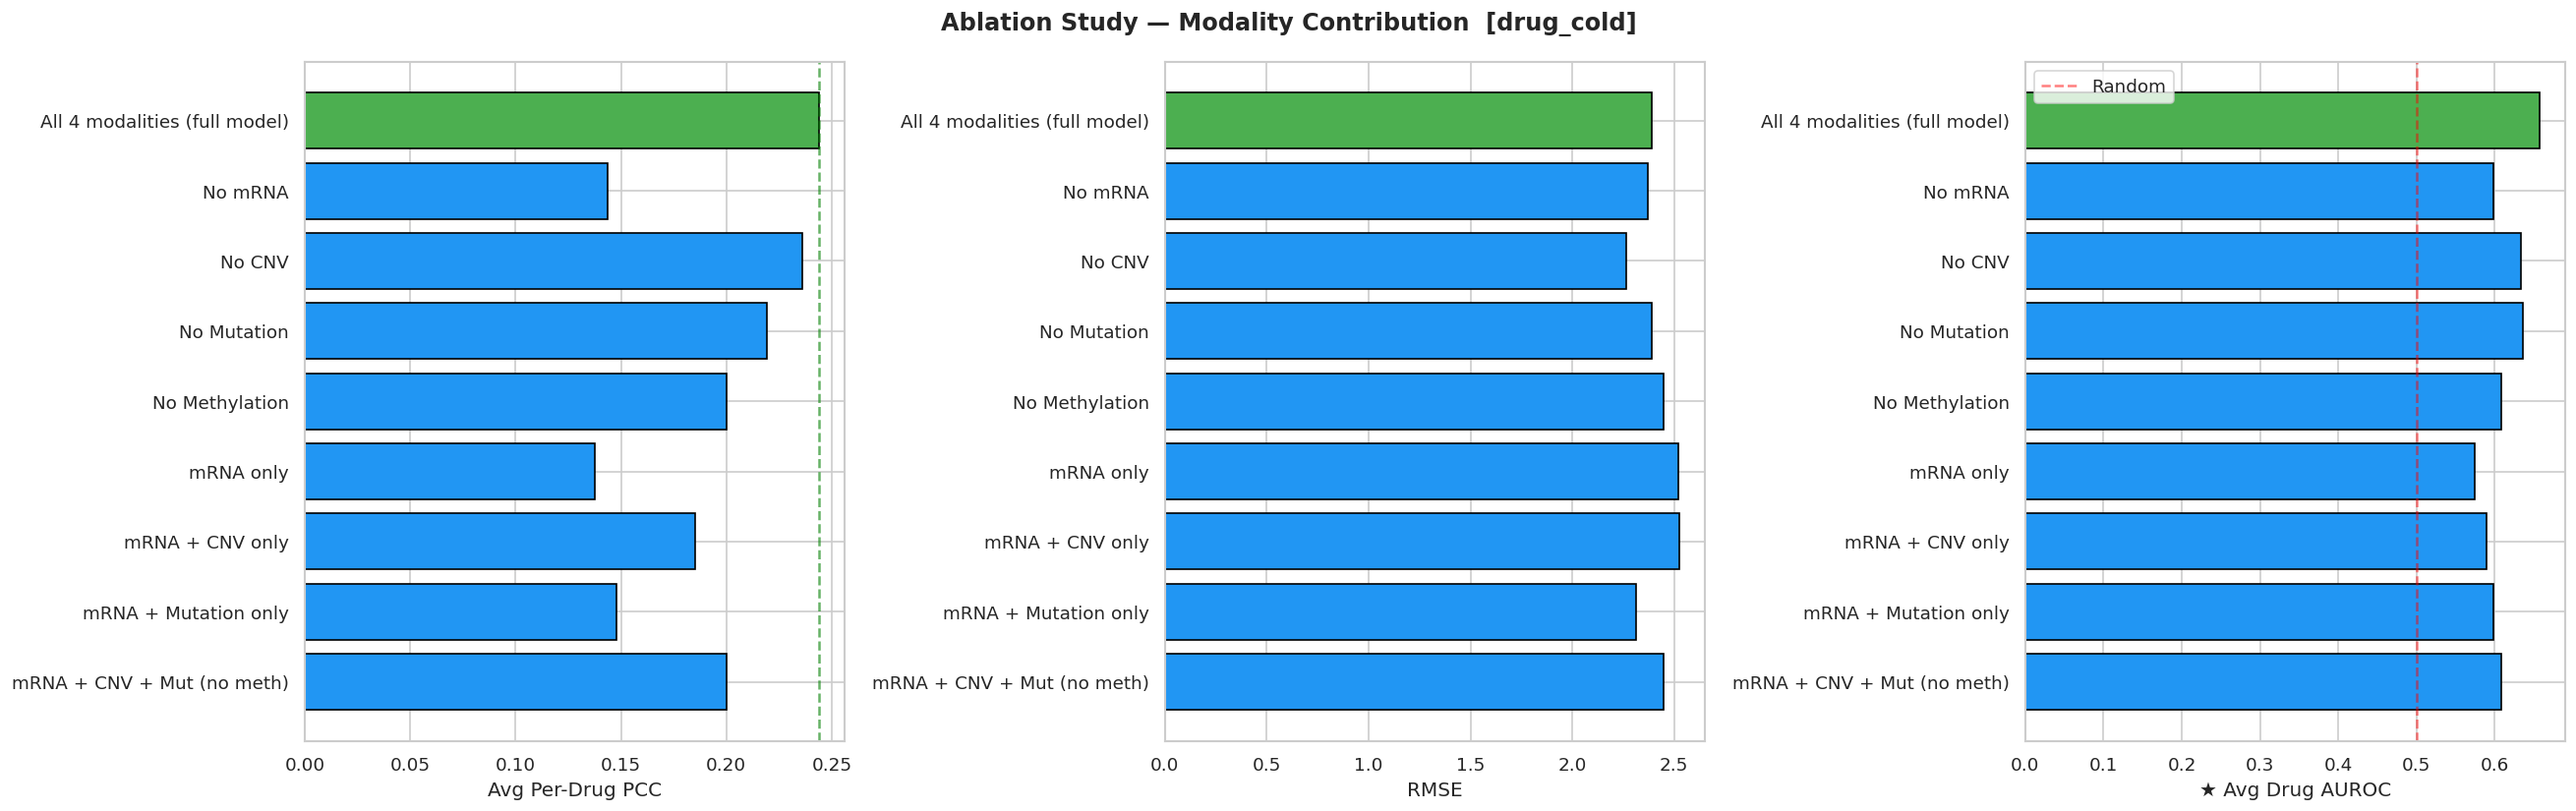

Saved: ablation_results_drug_cold.csv


In [13]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 13 — ABLATION STUDY  (modality zeroing on active test set)
#  [C5] ablation_eval() now passes `morgan_fp` from each batch.
# ═══════════════════════════════════════════════════════════════════════
section('13. ABLATION STUDY')

def ablation_eval(model, loader, zero_mods=None):
    model.eval()
    all_p, all_t, all_d = [], [], []
    with torch.no_grad():
        for b in loader:
            mrna = b['mrna'].to(DEVICE);  cnv  = b['cnv'].to(DEVICE)
            mut  = b['mut'].to(DEVICE);   meth = b['meth'].to(DEVICE)
            ids  = b['input_ids'].to(DEVICE)
            mask = b['attention_mask'].to(DEVICE)
            fp   = b['morgan_fp'].to(DEVICE)          # [C5]
            ic50 = b['ic50'].to(DEVICE)
            if zero_mods:
                if 'mrna' in zero_mods: mrna = torch.zeros_like(mrna)
                if 'cnv'  in zero_mods: cnv  = torch.zeros_like(cnv)
                if 'mut'  in zero_mods: mut  = torch.zeros_like(mut)
                if 'meth' in zero_mods: meth = torch.zeros_like(meth)
            pred = model(mrna, cnv, mut, meth, ids, mask, fp).squeeze(1)  # [C5]
            all_p.append(pred.cpu().numpy())
            all_t.append(ic50.cpu().numpy())
            all_d.append(b['drug_idx'].numpy())
    p = np.concatenate(all_p); t = np.concatenate(all_t); d = np.concatenate(all_d)
    m = compute_metrics(p, t, d, id_to_drug)
    return m['avg_drug_pearson'], m['pearson'], m['rmse'], m['r2'], m['avg_drug_auroc']


ablation_configs = [
    ('All 4 modalities (full model)',  []),
    ('No mRNA',                        ['mrna']),
    ('No CNV',                         ['cnv']),
    ('No Mutation',                    ['mut']),
    ('No Methylation',                 ['meth']),
    ('mRNA only',                      ['cnv', 'mut', 'meth']),
    ('mRNA + CNV only',                ['mut', 'meth']),
    ('mRNA + Mutation only',           ['cnv', 'meth']),
    ('mRNA + CNV + Mut (no meth)',     ['meth']),
]

print(f'Running ablation on {SPLIT_MODE.upper()} test set...')
print(f'  {"Setting":<40} {"DrugPCC":>9} {"GlobalPCC":>10} '
      f'{"RMSE":>7} {"R²":>7} {"AUROC":>8}')
print(f'  {"-"*85}')

abl_results = []
for name, zero_mods in ablation_configs:
    dp, gp, rmse, r2, auroc = ablation_eval(model, test_loader, zero_mods)
    auc_str = f'{auroc:.4f}' if not np.isnan(auroc) else '  N/A'
    abl_results.append({
        'Setting': name, 'AvgDrugPCC': round(dp, 4),
        'GlobalPCC': round(gp, 4), 'RMSE': round(rmse, 4),
        'R2': round(r2, 4),
        'AUROC': round(auroc, 4) if not np.isnan(auroc) else None})
    print(f'  {name:<40} {dp:>9.4f} {gp:>10.4f} {rmse:>7.4f} '
          f'{r2:>7.4f} {auc_str:>8}')

abl_df = pd.DataFrame(abl_results)
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(f'Ablation Study — Modality Contribution  [{SPLIT_MODE}]',
             fontweight='bold')
colors = ['#4CAF50' if i == 0 else '#2196F3' for i in range(len(abl_df))]
axes[0].barh(abl_df['Setting'], abl_df['AvgDrugPCC'],
             color=colors, edgecolor='black')
axes[0].axvline(abl_df.iloc[0]['AvgDrugPCC'], color='green', ls='--', alpha=0.6)
axes[0].set_xlabel('Avg Per-Drug PCC'); axes[0].invert_yaxis()
axes[1].barh(abl_df['Setting'], abl_df['RMSE'],
             color=colors, edgecolor='black')
axes[1].set_xlabel('RMSE'); axes[1].invert_yaxis()
auroc_vals_abl = [v if v is not None else 0.0 for v in abl_df['AUROC']]
axes[2].barh(abl_df['Setting'], auroc_vals_abl, color=colors, edgecolor='black')
axes[2].axvline(0.5, color='red', ls='--', alpha=0.5, label='Random')
axes[2].set_xlabel('★ Avg Drug AUROC'); axes[2].invert_yaxis(); axes[2].legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}ablation_study_{SPLIT_MODE}.png', dpi=150)
plt.show()
abl_df.to_csv(f'{OUT_DIR}ablation_results_{SPLIT_MODE}.csv', index=False)
print(f'Saved: ablation_results_{SPLIT_MODE}.csv')


══════════════════════════════════════════════════════════════════════
  14. DELTA IC50 — CLUSTERMAP + CANCER HEATMAP + RANKINGS
══════════════════════════════════════════════════════════════════════
Delta IC50 stats:
  Range : [-4.954, 1.511]
  Mean  : -0.0000
  Std   : 0.7593

Cancer type column: "OncotreePrimaryDisease"  (51 unique types)

Clustermap matrix: 11 drugs × 21 cell lines


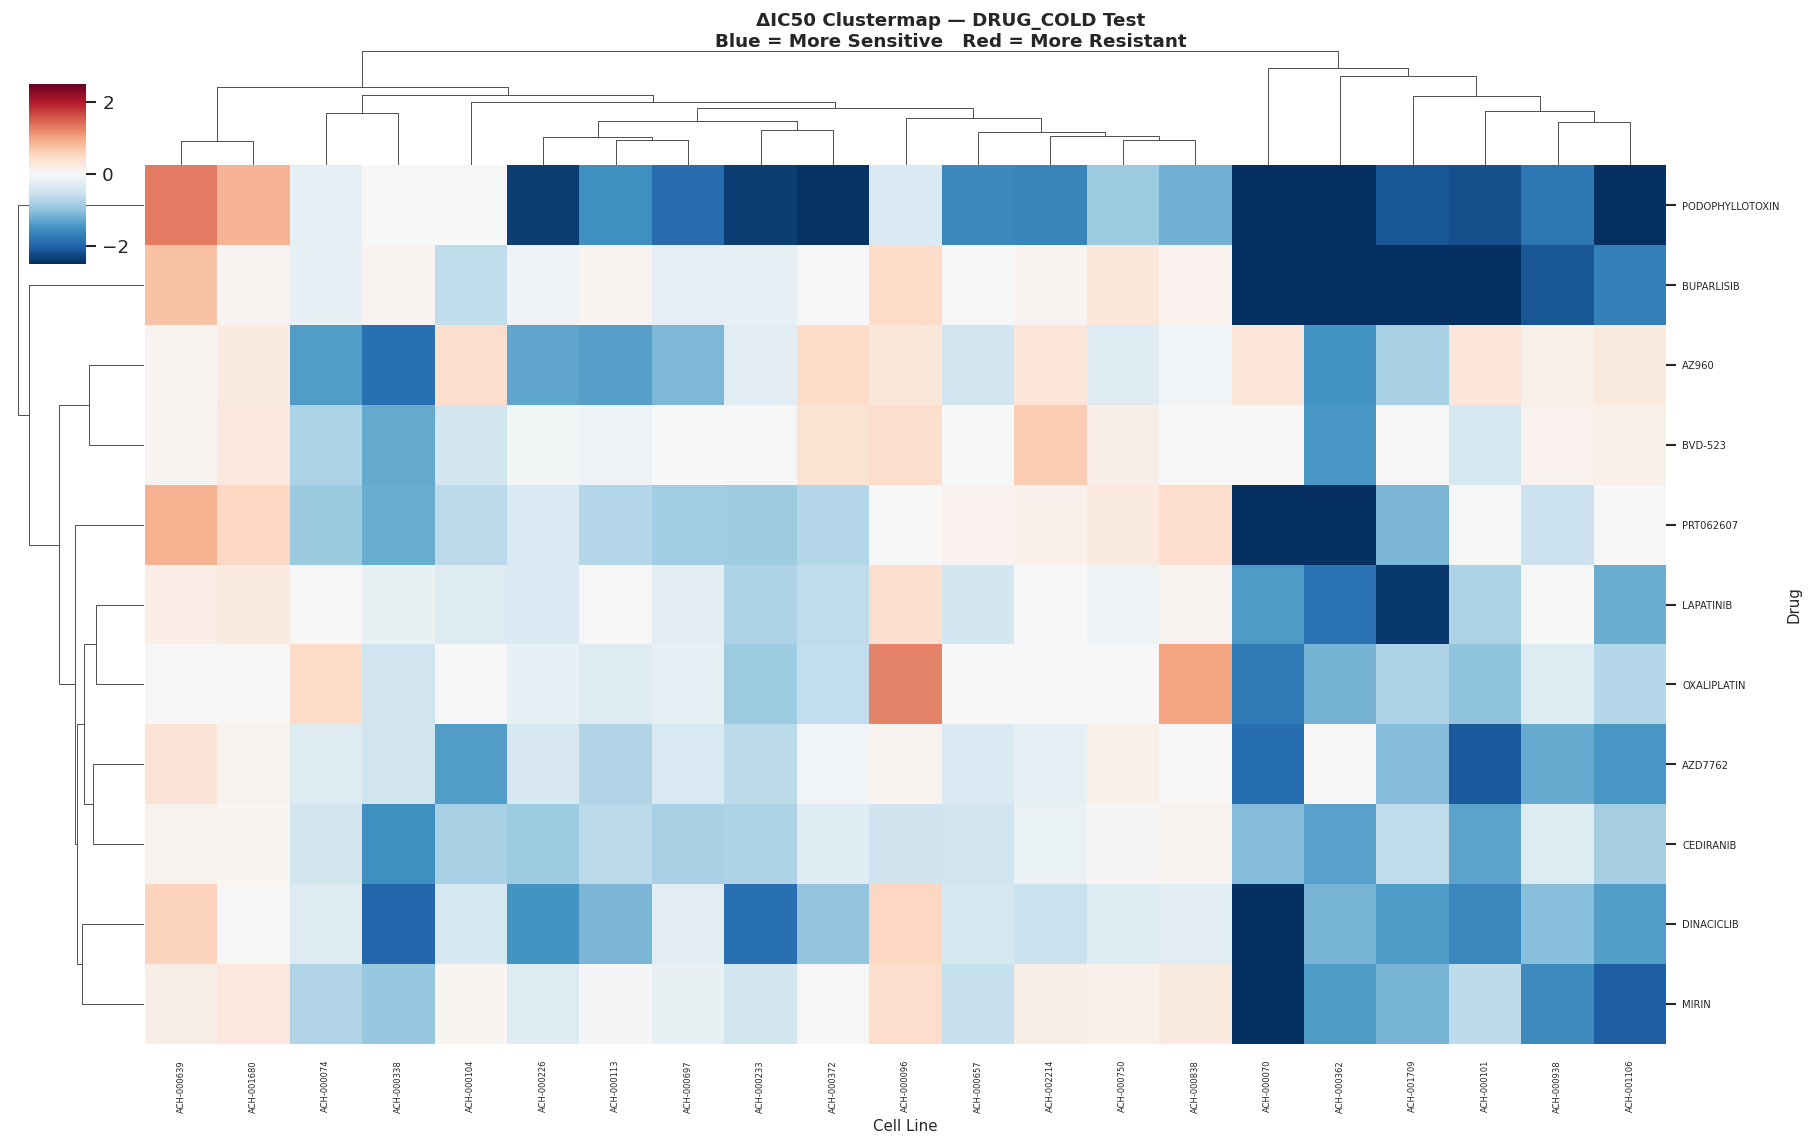

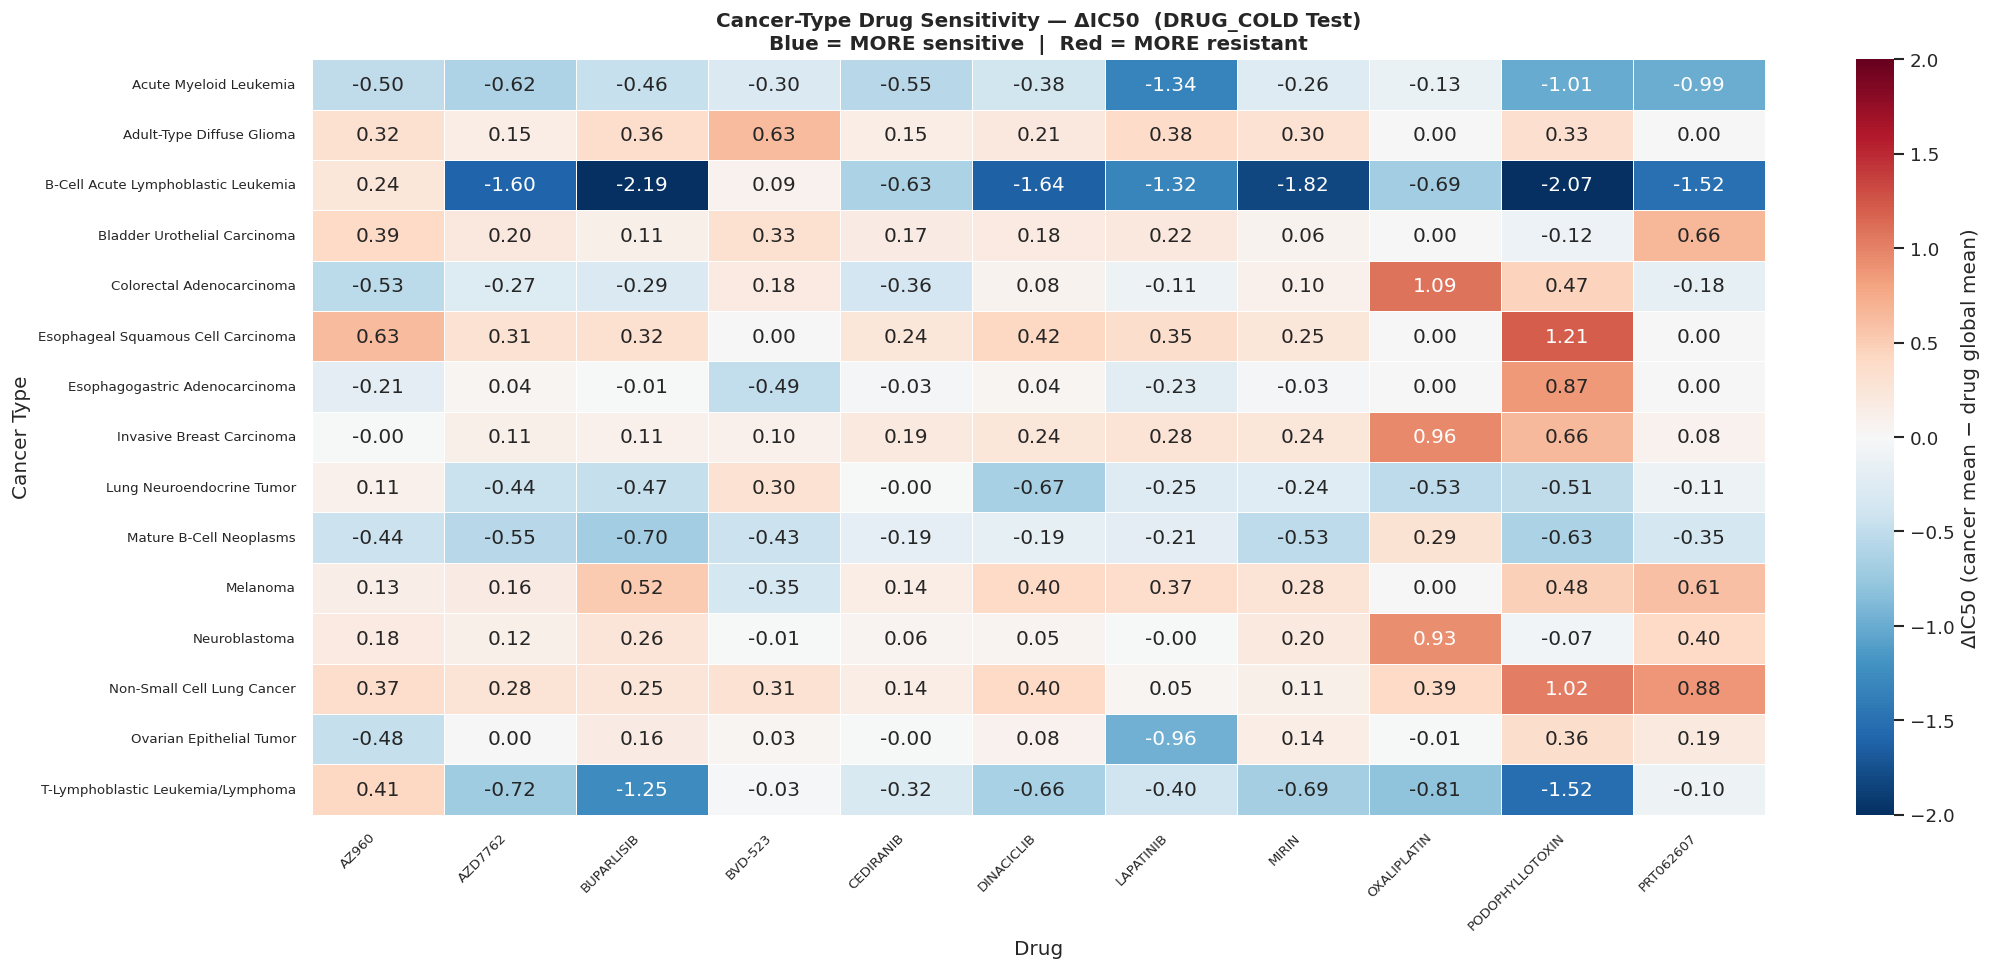


Saved: drug_rankings_delta_drug_cold.csv

Top 10 most SENSITIVE cell-drug pairs:
 cell_line  drug_name  true_ic50  pred_ic50  delta_ic50
ACH-000050 BUPARLISIB    -0.6719    -3.2129     -4.9537
ACH-000070 BUPARLISIB    -0.0586    -2.5527     -4.2935
ACH-000050      MIRIN     4.2731    -2.7773     -4.2239
ACH-001709 BUPARLISIB     0.5893    -2.2734     -4.0142
ACH-000977 BUPARLISIB     0.4550    -2.2520     -3.9928
ACH-000763      MIRIN     4.2141    -2.2656     -3.7122
ACH-000050    AZD7762    -0.1255    -2.5449     -3.5573
ACH-000070      MIRIN     4.3083    -2.0957     -3.5423
ACH-000763 BUPARLISIB     0.2290    -1.6143     -3.3551
ACH-000101 BUPARLISIB     0.0771    -1.5654     -3.3062

Saved: delta_ic50_drug_cold.csv


In [14]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 14 — DELTA IC50 ANALYSIS: CELL-LINE CLUSTERMAP + CANCER HEATMAP
#  Unchanged from v4 (uses updated te_preds / te_targets / te_drug_ids).
# ═══════════════════════════════════════════════════════════════════════
section('14. DELTA IC50 — CLUSTERMAP + CANCER HEATMAP + RANKINGS')

test_reset = ic50_test.reset_index(drop=True)
delta_df = pd.DataFrame({
    'pred_ic50' : te_preds.astype(np.float64),
    'true_ic50' : te_targets.astype(np.float64),
    'drug_idx'  : te_drug_ids,
})
delta_df['drug_name'] = delta_df['drug_idx'].map(id_to_drug)
delta_df['cell_line'] = test_reset['ModelID'].values

drug_mean_pred             = delta_df.groupby('drug_name')['pred_ic50'].mean()
delta_df['drug_mean_pred'] = delta_df['drug_name'].map(drug_mean_pred)
delta_df['delta_ic50']     = delta_df['pred_ic50'] - delta_df['drug_mean_pred']

print('Delta IC50 stats:')
print(f'  Range : [{delta_df["delta_ic50"].min():.3f}, {delta_df["delta_ic50"].max():.3f}]')
print(f'  Mean  : {delta_df["delta_ic50"].mean():.4f}')
print(f'  Std   : {delta_df["delta_ic50"].std():.4f}')

CANCER_COL = None
for _c in ['cancer_type', 'OncotreePrimaryDisease', 'tissue', 'TissueType', 'Tissue']:
    if _c in test_reset.columns:
        CANCER_COL = _c
        print(f'\nCancer type column: "{CANCER_COL}"  '
              f'({test_reset[CANCER_COL].nunique()} unique types)')
        break
if CANCER_COL is None:
    print(f'\nWARNING: No cancer type column found.  '
          f'Available: {test_reset.columns.tolist()}')

if CANCER_COL:
    delta_df['cancer_type'] = test_reset[CANCER_COL].values

MIN_DRUG_COVERAGE = 15
MIN_CL_COVERAGE   = 10
drug_counts = delta_df['drug_name'].value_counts()
cl_counts   = delta_df['cell_line'].value_counts()
keep_drugs  = drug_counts[drug_counts >= MIN_DRUG_COVERAGE].index
keep_cls    = cl_counts  [cl_counts   >= MIN_CL_COVERAGE ].index

filtered = delta_df[
    delta_df['drug_name'].isin(keep_drugs) &
    delta_df['cell_line'].isin(keep_cls)
]
pivot_cl = filtered.pivot_table(
    index='drug_name', columns='cell_line',
    values='delta_ic50', aggfunc='mean')

MAX_DRUGS, MAX_CLS = 40, 50
pivot_cl = pivot_cl.iloc[:MAX_DRUGS, :MAX_CLS]
pivot_cl = pivot_cl.dropna(axis=0, thresh=max(1, int(pivot_cl.shape[1] * 0.5)))
pivot_cl = pivot_cl.dropna(axis=1, thresh=max(1, int(pivot_cl.shape[0] * 0.5)))
pivot_cl = pivot_cl.fillna(0.0)
print(f'\nClustermap matrix: {pivot_cl.shape[0]} drugs × {pivot_cl.shape[1]} cell lines')

if pivot_cl.shape[0] >= 2 and pivot_cl.shape[1] >= 2:
    g = sns.clustermap(
        pivot_cl, cmap='RdBu_r', center=0, vmin=-2.5, vmax=2.5,
        figsize=(max(16, pivot_cl.shape[1] * 0.28),
                 max(10, pivot_cl.shape[0] * 0.35)),
        row_cluster=True, col_cluster=True,
        xticklabels=True, yticklabels=True,
        dendrogram_ratio=(0.08, 0.12),
        cbar_pos=(0.02, 0.80, 0.03, 0.15),
        linewidths=0,
    )
    g.ax_heatmap.set_xlabel('Cell Line', fontsize=9)
    g.ax_heatmap.set_ylabel('Drug', fontsize=9)
    g.ax_heatmap.set_xticklabels(
        g.ax_heatmap.get_xticklabels(), fontsize=5, rotation=90)
    g.ax_heatmap.set_yticklabels(
        g.ax_heatmap.get_yticklabels(), fontsize=6, rotation=0)
    g.fig.suptitle(
        f'ΔIC50 Clustermap — {SPLIT_MODE.upper()} Test\n'
        'Blue = More Sensitive   Red = More Resistant',
        y=1.01, fontweight='bold', fontsize=11)

plt.savefig(f'{OUT_DIR}delta_ic50_heatmap_{SPLIT_MODE}.png', dpi=150, bbox_inches='tight')
plt.show()

if CANCER_COL:
    TOP_N_CANCERS = 15; TOP_N_DRUGS = 25
    top_cancers  = delta_df['cancer_type'].value_counts().head(TOP_N_CANCERS).index
    top_drugs_cv = delta_df['drug_name'].value_counts().head(TOP_N_DRUGS).index
    pivot_cancer = (
        delta_df[delta_df['cancer_type'].isin(top_cancers) &
                 delta_df['drug_name'].isin(top_drugs_cv)]
        .groupby(['cancer_type', 'drug_name'])['delta_ic50']
        .mean().unstack(fill_value=0.0))
    if not pivot_cancer.empty:
        plt.figure(figsize=(max(18, len(top_drugs_cv) * 0.7),
                             max(7,  len(top_cancers)  * 0.55)))
        sns.heatmap(pivot_cancer, cmap='RdBu_r', center=0, vmin=-2.0, vmax=2.0,
                    annot=True, fmt='.2f', linewidths=0.3,
                    cbar_kws={'label': 'ΔIC50 (cancer mean − drug global mean)'})
        plt.title(
            f'Cancer-Type Drug Sensitivity — ΔIC50  ({SPLIT_MODE.upper()} Test)\n'
            'Blue = MORE sensitive  |  Red = MORE resistant',
            fontsize=12, fontweight='bold')
        plt.xlabel('Drug'); plt.ylabel('Cancer Type')
        plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(fontsize=8)
        plt.tight_layout()
        plt.savefig(f'{OUT_DIR}delta_ic50_heatmap_cancer_{SPLIT_MODE}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

if CANCER_COL:
    drug_ranking = (
        delta_df
        .groupby(['cancer_type', 'drug_name'])
        .agg(mean_delta_ic50=('delta_ic50', 'mean'),
             mean_pred_ic50 =('pred_ic50',  'mean'),
             mean_true_ic50 =('true_ic50',  'mean'),
             std_pred_ic50  =('pred_ic50',  'std'),
             n_cell_lines   =('cell_line',  'nunique'))
        .reset_index())
    top5_per_cancer = (
        drug_ranking.sort_values(['cancer_type', 'mean_delta_ic50'])
        .groupby('cancer_type').head(5))
    top5_per_cancer.to_csv(
        f'{OUT_DIR}drug_rankings_delta_{SPLIT_MODE}.csv', index=False)
    print(f'\nSaved: drug_rankings_delta_{SPLIT_MODE}.csv')

delta_df_sorted = delta_df.sort_values('delta_ic50')
print('\nTop 10 most SENSITIVE cell-drug pairs:')
print(delta_df_sorted[['cell_line','drug_name','true_ic50','pred_ic50','delta_ic50']]
      .head(10).round(4).to_string(index=False))

delta_df.to_csv(f'{OUT_DIR}delta_ic50_{SPLIT_MODE}.csv', index=False)
print(f'\nSaved: delta_ic50_{SPLIT_MODE}.csv')


══════════════════════════════════════════════════════════════════════
  15. SENSITIVITY RANK CONCORDANCE
══════════════════════════════════════════════════════════════════════
Drugs evaluated: 11

Rank Spearman ρ:
  Mean   : 0.2933
  Median : 0.3267
  % > 0.5: 9.1%
  % > 0.7: 0.0%

Top-5 Sensitive Recall:
  Mean   : 0.1455
  Median : 0.2000


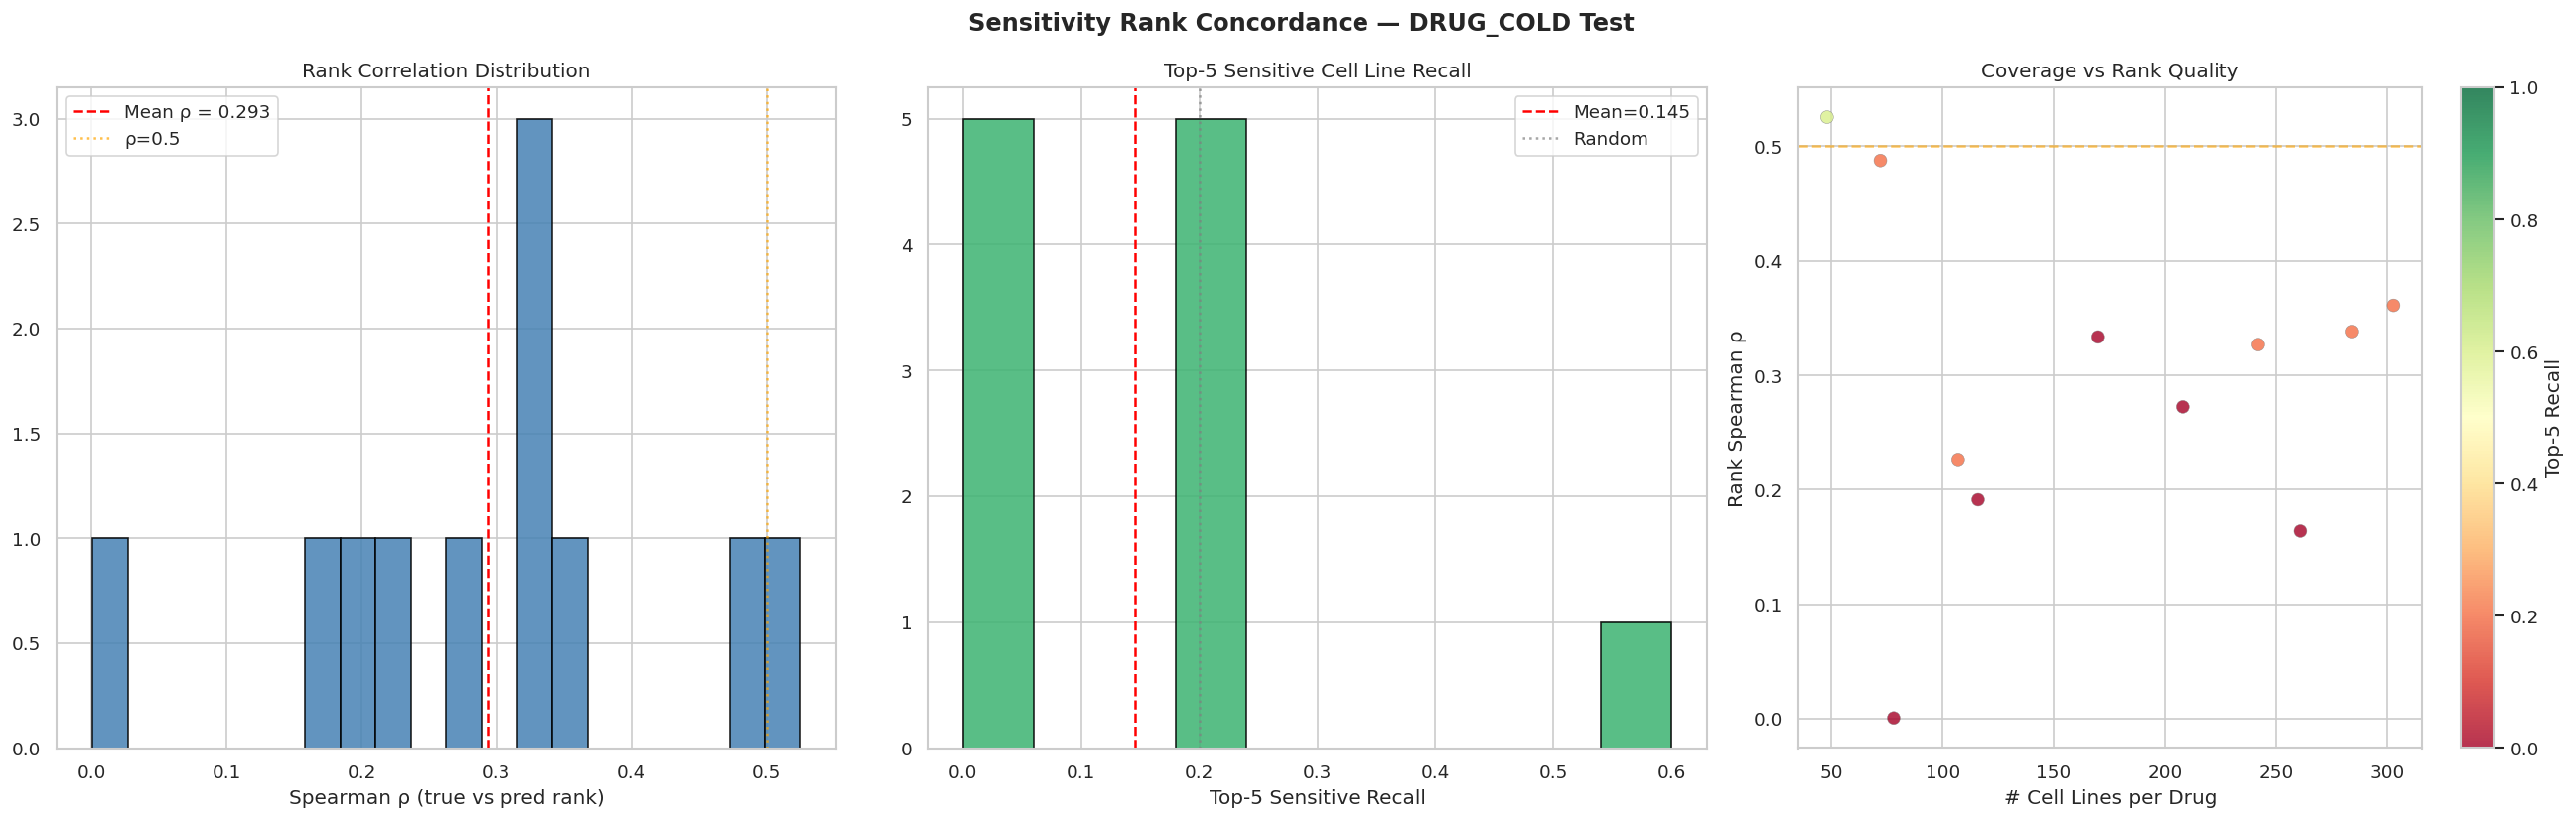

Saved: rank_concordance_drug_cold.csv

Top 10 drugs (best rank concordance):
           drug  n_cell_lines  rank_rho  topk_recall
    OXALIPLATIN            48    0.5254          0.6
      PRT062607            72    0.4875          0.2
        AZD7762           303    0.3610          0.2
     BUPARLISIB           284    0.3381          0.2
PODOPHYLLOTOXIN           170    0.3334          0.0
     DINACICLIB           242    0.3267          0.2
          MIRIN           208    0.2723          0.0
          AZ960           107    0.2263          0.2
      LAPATINIB           116    0.1911          0.0
      CEDIRANIB           261    0.1638          0.0


In [15]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 15 — SENSITIVITY RANK CONCORDANCE  (unchanged from v4)
# ═══════════════════════════════════════════════════════════════════════
section('15. SENSITIVITY RANK CONCORDANCE')

TOP_K = 5
rank_records = []
for drug_name, grp in delta_df.groupby('drug_name'):
    if len(grp) < 8:
        continue
    grp = grp.copy()
    grp['true_ic50'] = grp['true_ic50'].astype(np.float64)
    grp['pred_ic50'] = grp['pred_ic50'].astype(np.float64)
    true_ranks = grp['true_ic50'].rank()
    pred_ranks = grp['pred_ic50'].rank()
    rho, pval  = spearmanr(true_ranks, pred_ranks)
    k = min(TOP_K, max(1, len(grp) // 5))
    true_top_k = set(grp.nsmallest(k, 'true_ic50').index)
    pred_top_k = set(grp.nsmallest(k, 'pred_ic50').index)
    topk_recall = len(true_top_k & pred_top_k) / k
    rank_records.append({
        'drug': drug_name, 'n_cell_lines': len(grp),
        'rank_rho': round(rho, 4), 'rank_pval': round(pval, 4),
        'topk_recall': round(topk_recall, 4), 'k_used': k,
    })

rank_df = pd.DataFrame(rank_records).sort_values('rank_rho', ascending=False)
print(f'Drugs evaluated: {len(rank_df)}')
print(f'\nRank Spearman ρ:')
print(f'  Mean   : {rank_df["rank_rho"].mean():.4f}')
print(f'  Median : {rank_df["rank_rho"].median():.4f}')
print(f'  % > 0.5: {(rank_df["rank_rho"] > 0.5).mean()*100:.1f}%')
print(f'  % > 0.7: {(rank_df["rank_rho"] > 0.7).mean()*100:.1f}%')
print(f'\nTop-{TOP_K} Sensitive Recall:')
print(f'  Mean   : {rank_df["topk_recall"].mean():.4f}')
print(f'  Median : {rank_df["topk_recall"].median():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(f'Sensitivity Rank Concordance — {SPLIT_MODE.upper()} Test',
             fontweight='bold')
axes[0].hist(rank_df['rank_rho'], bins=20, color='steelblue',
             edgecolor='black', alpha=0.85)
axes[0].axvline(rank_df['rank_rho'].mean(), color='red', ls='--',
                label=f'Mean ρ = {rank_df["rank_rho"].mean():.3f}')
axes[0].axvline(0.5, color='orange', ls=':', alpha=0.7, label='ρ=0.5')
axes[0].set_xlabel('Spearman ρ (true vs pred rank)')
axes[0].set_title('Rank Correlation Distribution'); axes[0].legend()
axes[1].hist(rank_df['topk_recall'], bins=10, color='mediumseagreen',
             edgecolor='black', alpha=0.85)
axes[1].axvline(rank_df['topk_recall'].mean(), color='red', ls='--',
                label=f'Mean={rank_df["topk_recall"].mean():.3f}')
axes[1].axvline(1/TOP_K, color='grey', ls=':', alpha=0.7, label='Random')
axes[1].set_xlabel(f'Top-{TOP_K} Sensitive Recall')
axes[1].set_title(f'Top-{TOP_K} Sensitive Cell Line Recall'); axes[1].legend()
sc = axes[2].scatter(
    rank_df['n_cell_lines'], rank_df['rank_rho'],
    c=rank_df['topk_recall'], cmap='RdYlGn',
    vmin=0, vmax=1, s=60, alpha=0.8, edgecolors='grey', linewidths=0.3)
plt.colorbar(sc, ax=axes[2], label=f'Top-{TOP_K} Recall')
axes[2].axhline(0.5, color='orange', ls='--', alpha=0.6)
axes[2].set_xlabel('# Cell Lines per Drug'); axes[2].set_ylabel('Rank Spearman ρ')
axes[2].set_title('Coverage vs Rank Quality')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}rank_concordance_{SPLIT_MODE}.png', dpi=150)
plt.show()
rank_df.to_csv(f'{OUT_DIR}rank_concordance_{SPLIT_MODE}.csv', index=False)
print(f'Saved: rank_concordance_{SPLIT_MODE}.csv')
print(f'\nTop 10 drugs (best rank concordance):')
print(rank_df[['drug', 'n_cell_lines', 'rank_rho', 'topk_recall']].head(10)
      .to_string(index=False))


══════════════════════════════════════════════════════════════════════
  16. DRUG EMBEDDING PCA
══════════════════════════════════════════════════════════════════════
Encoding 11 unique drugs through ChemBERTa + Morgan...
Embedding matrix: (11, 384)
PCA explained variance: PC1=19.8%  PC2=15.1%


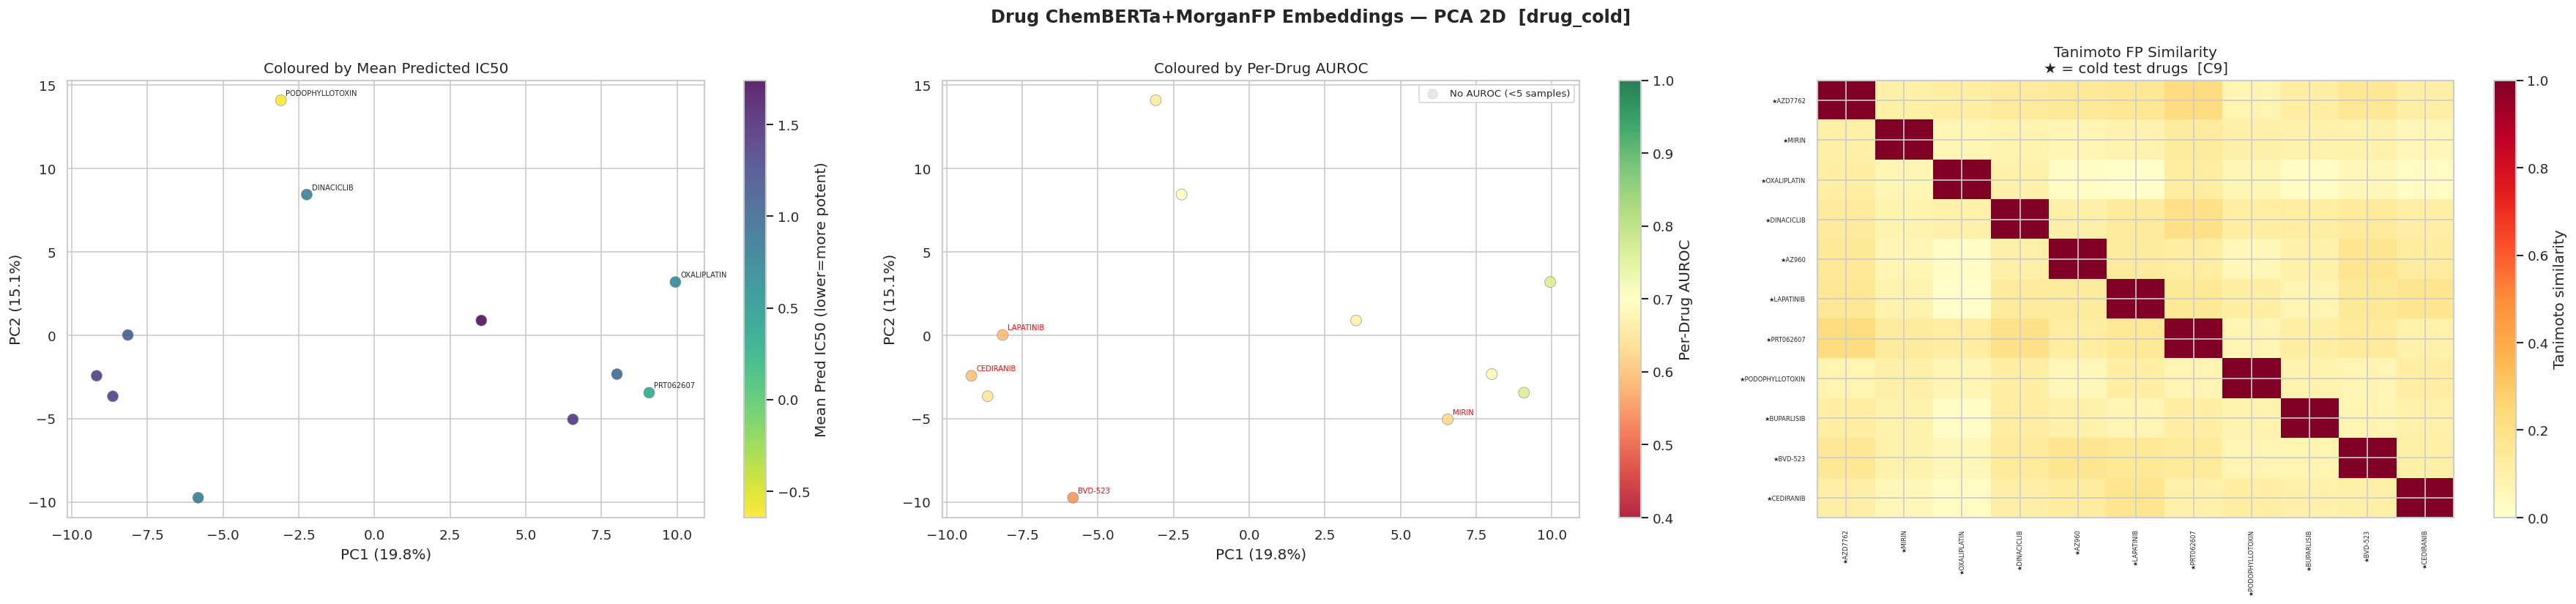

Saved: drug_embeddings_pca_drug_cold.csv

Drugs with lowest AUROC (model struggles to rank these):
      drug_name  mean_pred_ic50  auroc
        BVD-523          0.8158 0.5523
      LAPATINIB          1.1201 0.5936
      CEDIRANIB          1.4000 0.5979
          MIRIN          1.4466 0.6301
          AZ960          1.3511 0.6497
PODOPHYLLOTOXIN         -0.6434 0.6558
     BUPARLISIB          1.7408 0.6689
        AZD7762          1.0123 0.6868

  NOTEBOOK COMPLETE — OncoBridge v5
  Split mode      : drug_cold
  Checkpoint metric: avg_drug_auroc
  Final avg_drug_auroc : 0.6932


In [16]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 16 — DRUG EMBEDDING PCA
#  [C5] Passes morgan_fp to drug_encoder when extracting embeddings.
#       Adds a Tanimoto similarity heatmap panel (drug-cold only).
# ═══════════════════════════════════════════════════════════════════════
section('16. DRUG EMBEDDING PCA')

m_mod = get_module(model)
m_mod.eval()

unique_drugs = delta_df[['drug_name']].drop_duplicates()
unique_drugs['smiles'] = unique_drugs['drug_name'].map(
    lambda d: smiles_map.get(d, 'C') or 'C')
unique_drugs = unique_drugs.reset_index(drop=True)

print(f'Encoding {len(unique_drugs)} unique drugs through ChemBERTa + Morgan...')

embed_list, name_list = [], []
EMBED_BS = 64

with torch.no_grad():
    for start in range(0, len(unique_drugs), EMBED_BS):
        chunk = unique_drugs.iloc[start: start + EMBED_BS]
        enc = tokenizer(
            chunk['smiles'].tolist(),
            max_length=CONFIG['chemberta_max_len'],
            padding='max_length', truncation=True, return_tensors='pt')
        ids_  = enc['input_ids'].to(DEVICE)
        mask_ = enc['attention_mask'].to(DEVICE)
        # [C5] Build Morgan FP batch for these drugs
        fp_rows = [drug_to_morgan_idx.get(d, 0) for d in chunk['drug_name'].tolist()]
        fp_     = torch.from_numpy(
            morgan_fp_matrix[fp_rows]).float().to(DEVICE)
        emb = m_mod.drug_encoder(ids_, mask_, fp_).cpu().numpy()  # [C5]
        embed_list.append(emb)
        name_list.extend(chunk['drug_name'].tolist())

embed_matrix = np.vstack(embed_list)
print(f'Embedding matrix: {embed_matrix.shape}')

pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embed_matrix)
print(f'PCA explained variance: '
      f'PC1={pca.explained_variance_ratio_[0]*100:.1f}%  '
      f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

embed_df = pd.DataFrame({
    'drug_name': name_list,
    'pc1': coords[:, 0],
    'pc2': coords[:, 1],
})
drug_stats = delta_df.groupby('drug_name').agg(
    mean_pred_ic50=('pred_ic50', 'mean'),
    mean_true_ic50=('true_ic50', 'mean'),
).reset_index()
auroc_lookup = {name: vals['auroc'] for name, vals in te_results['per_drug'].items()}
drug_stats['auroc'] = drug_stats['drug_name'].map(auroc_lookup)
embed_df = embed_df.merge(drug_stats, on='drug_name', how='left')

n_panels = 3 if SPLIT_MODE == 'drug_cold' else 2
fig, axes = plt.subplots(1, n_panels, figsize=(10 * n_panels, 7))
fig.suptitle(f'Drug ChemBERTa+MorganFP Embeddings — PCA 2D  [{SPLIT_MODE}]',
             fontweight='bold')

sc1 = axes[0].scatter(
    embed_df['pc1'], embed_df['pc2'],
    c=embed_df['mean_pred_ic50'], cmap='viridis_r',
    s=80, alpha=0.85, edgecolors='grey', linewidths=0.4)
plt.colorbar(sc1, ax=axes[0], label='Mean Pred IC50 (lower=more potent)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Coloured by Mean Predicted IC50')
for _, row in embed_df.nsmallest(4, 'mean_pred_ic50').iterrows():
    axes[0].annotate(row['drug_name'], (row['pc1'], row['pc2']),
                     fontsize=6, xytext=(4, 4), textcoords='offset points')

valid_auroc = embed_df.dropna(subset=['auroc'])
sc2 = axes[1].scatter(
    valid_auroc['pc1'], valid_auroc['pc2'],
    c=valid_auroc['auroc'], cmap='RdYlGn', vmin=0.4, vmax=1.0,
    s=80, alpha=0.85, edgecolors='grey', linewidths=0.4)
no_auroc = embed_df[embed_df['auroc'].isna()]
axes[1].scatter(no_auroc['pc1'], no_auroc['pc2'],
                color='lightgrey', s=60, alpha=0.5, label='No AUROC (<5 samples)')
plt.colorbar(sc2, ax=axes[1], label='Per-Drug AUROC')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Coloured by Per-Drug AUROC'); axes[1].legend(fontsize=8)
for _, row in valid_auroc.nsmallest(4, 'auroc').iterrows():
    axes[1].annotate(row['drug_name'], (row['pc1'], row['pc2']),
                     fontsize=6, color='red', xytext=(4, 4), textcoords='offset points')

# [C9] Panel 3: Tanimoto similarity heatmap (drug-cold only)
if SPLIT_MODE == 'drug_cold' and n_panels == 3:
    all_drug_names = embed_df['drug_name'].tolist()
    all_fp_rows    = [drug_to_morgan_idx.get(d, 0) for d in all_drug_names]
    all_fps        = morgan_fp_matrix[all_fp_rows]
    tan_mat        = _tanimoto_matrix(all_fps, all_fps)
    test_drug_set  = set(ic50_test['DRUG_NAME'].unique())
    row_labels     = ['★' + d if d in test_drug_set else d
                      for d in all_drug_names]
    im = axes[2].imshow(tan_mat, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
    plt.colorbar(im, ax=axes[2], label='Tanimoto similarity')
    axes[2].set_xticks(range(len(all_drug_names)))
    axes[2].set_yticks(range(len(all_drug_names)))
    axes[2].set_xticklabels(row_labels, rotation=90, fontsize=5)
    axes[2].set_yticklabels(row_labels, fontsize=5)
    axes[2].set_title('Tanimoto FP Similarity\n★ = cold test drugs  [C9]')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}drug_embedding_pca_{SPLIT_MODE}.png', dpi=150)
plt.show()

embed_df.to_csv(f'{OUT_DIR}drug_embeddings_pca_{SPLIT_MODE}.csv', index=False)
print(f'Saved: drug_embeddings_pca_{SPLIT_MODE}.csv')
print(f'\nDrugs with lowest AUROC (model struggles to rank these):')
print(valid_auroc.nsmallest(8, 'auroc')[['drug_name', 'mean_pred_ic50', 'auroc']]
      .round(4).to_string(index=False))

print('\n' + '='*70)
print('  NOTEBOOK COMPLETE — OncoBridge v5')
print(f'  Split mode      : {SPLIT_MODE}')
print(f'  Checkpoint metric: {CKPT_METRIC}')
print(f'  Final {CKPT_METRIC} : {best_s2:.4f}')
print('='*70)